# Headline

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Download

In [3]:
!pip install -U --extra-index-url https://vnstocks.com/api/simple vnstock

Looking in indexes: https://pypi.org/simple, https://vnstocks.com/api/simple
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.0/287.0 kB 373.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 3.2 MB/s eta 0:00:00


## Import

In [4]:
# 1. Thư viện chuẩn & Cấu hình cảnh báo
import math
import os
import pickle
import time
import warnings
from abc import ABC, abstractmethod
from collections import defaultdict
from typing import Optional, Sequence

from statsmodels.tools.sm_exceptions import InterpolationWarning

warnings.filterwarnings("ignore")
warnings.simplefilter("ignore", InterpolationWarning)

# 2. Xử lý & Trực quan hóa dữ liệu, Lấy dữ liệu tài chính
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import vnstock
import xgboost as xgb
import yfinance as yf

# 3. Khoa học & Xử lý tín hiệu (SciPy)
from scipy import stats
from scipy.cluster.hierarchy import fcluster, linkage
from scipy.fft import rfft, rfftfreq
from scipy.optimize import minimize
from scipy.spatial.distance import squareform
from scipy.special import expit

# 4. Thống kê & Chuỗi thời gian (Statsmodels)
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression
from statsmodels.tsa.stattools import acf, adfuller, bds, grangercausalitytests, kpss, pacf

# 5. Machine Learning & Đánh giá mô hình (Scikit-Learn)
from sklearn.base import BaseEstimator, ClassifierMixin, TransformerMixin, clone
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression
from sklearn.impute import SimpleImputer
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    mean_squared_error,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.utils.class_weight import compute_sample_weight

# Data Input

In [5]:
# =====================================================================
# BƯỚC: DATA PREPARATION (MULTI-ASSET DATA LOADER & CLEANING)
# =====================================================================
class MultiAssetDataPreparer:
    """
    Tải, kiểm toán hình học, chuẩn hóa giá điều chỉnh và lưu trữ dữ liệu
    cho toàn bộ rổ cổ phiếu trong final_portfolio.csv cùng chỉ số VN-Index.
    """
    def __init__(self, portfolio_path: str = 'final_portfolio.csv',
                 start_date: str = '2018-01-01', end_date: str = '2026-06-01',
                 source: str = 'KBS', cache_dir: str = 'data_cache'):
        self.portfolio_path = portfolio_path
        self.start_date = start_date
        self.end_date = end_date
        self.source = source
        self.cache_dir = cache_dir
        os.makedirs(self.cache_dir, exist_ok=True)

        # Đọc danh mục mục tiêu và trích xuất danh sách mã
        self.df_portfolio = pd.read_csv(self.portfolio_path)
        self.tickers = sorted(self.df_portfolio['Ticker'].unique().tolist())
        print(f"[*] Khởi tạo danh mục: {len(self.tickers)} mã cổ phiếu từ {self.portfolio_path}")

    def _fetch_history(self, symbol: str) -> pd.DataFrame:
        """Tải dữ liệu OHLCV từ Yahoo Finance để tránh bị chặn IP trên Colab."""
        cache_file = os.path.join(self.cache_dir, f"{symbol}.csv")

        if os.path.exists(cache_file):
            df = pd.read_csv(cache_file)
            df['time'] = pd.to_datetime(df['time'])
            df.set_index('time', inplace=True)
            return df

        try:
            # Chứng khoán VN trên Yahoo cần thêm hậu tố .VN (VD: VNINDEX.QA cho VN-Index, FPT.VN cho FPT)
            yf_symbol = "VNINDEX.QA" if symbol == "VNINDEX" else f"{symbol}.VN"

            ticker_obj = yf.Ticker(yf_symbol)
            df = ticker_obj.history(start=self.start_date, end=self.end_date, interval="1d")

            if df is not None and not df.empty:
                df.reset_index(inplace=True)

                # Đồng bộ tên cột với chuẩn code hiện tại của bạn
                df.rename(columns={
                    'Date': 'time', 'Open': 'open', 'High': 'high',
                    'Low': 'low', 'Close': 'close', 'Volume': 'volume'
                }, inplace=True)

                # Chuẩn hóa time (loại bỏ timezone nếu có)
                df['time'] = pd.to_datetime(df['time']).dt.tz_localize(None)
                df.sort_values(by='time', inplace=True)
                df.set_index('time', inplace=True)

                # Lưu file cache
                df.to_csv(cache_file)
                return df

        except Exception as err:
            print(f"  [!] Lỗi lấy dữ liệu {symbol} từ Yahoo Finance: {err}")

        return pd.DataFrame()

    def _clean_and_adjust(self, df: pd.DataFrame, df_mkt: pd.DataFrame) -> pd.DataFrame:
        """Kiểm toán hình học nến và bổ sung biến lợi nhuận thị trường."""
        df = df.copy()

        # 1. Khử trùng lặp và sắp xếp thứ tự thời gian
        df = df[~df.index.duplicated(keep='last')].sort_index()

        # 2. Kiểm toán biên hình học nến
        max_oc = df[['open', 'close']].max(axis=1)
        min_oc = df[['open', 'close']].min(axis=1)
        df['high'] = np.maximum(df['high'], max_oc)
        df['low'] = np.minimum(df['low'], min_oc)
        df = df[(df['low'] > 0) & (df['volume'] >= 0)]

        # 3. Chuẩn hóa giá điều chỉnh (nếu chưa có sẵn)
        if 'close_adj' not in df.columns:
            df['close_adj'] = df['close']
            ratio = df['close_adj'] / df['close']
            df['open_adj'] = df['open'] * ratio
            df['high_adj'] = df['high'] * ratio
            df['low_adj'] = df['low'] * ratio

        # 4. Tính các chuỗi Log Return cơ sở
        df['log_return'] = np.log(df['close_adj'] / df['close_adj'].shift(1))
        df['overnight_return'] = np.log(df['open_adj'] / df['close_adj'].shift(1))
        df['intraday_return'] = np.log(df['close_adj'] / df['open_adj'])
        df['hl_log_range'] = np.log(df['high_adj'] / df['low_adj'])

        # 5. Ghép lợi nhuận VN-Index làm biến ngoại sinh
        if not df_mkt.empty:
            df = df.join(df_mkt, how='left')
            df[df_mkt.columns] = df[df_mkt.columns].fillna(0.0)

        return df.dropna(subset=['close_adj', 'open_adj'])

    def prepare_dataset(self) -> dict[str, pd.DataFrame]:
        """Thực thi tải và làm sạch toàn bộ dữ liệu danh mục."""
        print("[*] Đang tải dữ liệu Benchmark VN-INDEX...")
        df_mkt = self._fetch_history('VNINDEX')
        if not df_mkt.empty:

            df_mkt.index = pd.to_datetime(df_mkt.index)
            df_mkt.sort_index(inplace=True)

            # Trích xuất các biến cơ bản của Market Benchmark
            df_mkt = df_mkt[['close', 'volume', 'high', 'low']].rename(columns={
                'close': 'mkt_close',
                'volume': 'mkt_volume',
                'high': 'mkt_high',
                'low': 'mkt_low'
            })
            df_mkt['mkt_return'] = np.log(df_mkt['mkt_close'] / df_mkt['mkt_close'].shift(1))


        clean_dict = {}
        for idx, ticker in enumerate(self.tickers, 1):
            print(f"[{idx:02d}/{len(self.tickers):02d}] Chuẩn bị dữ liệu: {ticker}...")
            df_raw = self._fetch_history(ticker)
            if not df_raw.empty and len(df_raw) > 50:
                clean_df = self._clean_and_adjust(df_raw, df_mkt)
                clean_dict[ticker] = clean_df
            else:
                print(f"  [!] Bỏ qua {ticker} (dữ liệu rỗng hoặc không đủ số phiên tối thiểu).")
            time.sleep(5)
        print(f"\n[✓] HOÀN TẤT BƯỚC DATA PREP: Sẵn sàng {len(clean_dict)}/{len(self.tickers)} mã cổ phiếu cho khâu Modeling.")
        return clean_dict

## Port. Index Preparation:

In [6]:
# =====================================================================
# THỰC THI CHUẨN BỊ DỮ LIỆU
# =====================================================================
portfolio_path = "/content/drive/MyDrive/Colab Notebooks/AI agent in Portfolio Management/Compiled Dataset/final_portfolio.csv"

data_preparer = MultiAssetDataPreparer(
    portfolio_path=portfolio_path,
    start_date='2018-01-01',
    end_date='2026-06-01',
    source='KBS'
)

clean_price_dict = data_preparer.prepare_dataset()

[*] Khởi tạo danh mục: 49 mã cổ phiếu từ /content/drive/MyDrive/Colab Notebooks/AI agent in Portfolio Management/Compiled Dataset/final_portfolio.csv
[*] Đang tải dữ liệu Benchmark VN-INDEX...


ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: VNINDEX.QA"}}}
ERROR:yfinance:$VNINDEX.QA: possibly delisted; no timezone found


[01/49] Chuẩn bị dữ liệu: ABT...
[02/49] Chuẩn bị dữ liệu: ADP...
[03/49] Chuẩn bị dữ liệu: BMP...
[04/49] Chuẩn bị dữ liệu: BRC...
[05/49] Chuẩn bị dữ liệu: CHP...
[06/49] Chuẩn bị dữ liệu: CSM...
[07/49] Chuẩn bị dữ liệu: CSV...
[08/49] Chuẩn bị dữ liệu: CTI...
[09/49] Chuẩn bị dữ liệu: DGC...
[10/49] Chuẩn bị dữ liệu: DHC...
[11/49] Chuẩn bị dữ liệu: DPR...
[12/49] Chuẩn bị dữ liệu: DRL...
[13/49] Chuẩn bị dữ liệu: DSN...
[14/49] Chuẩn bị dữ liệu: DVP...
[15/49] Chuẩn bị dữ liệu: FMC...
[16/49] Chuẩn bị dữ liệu: FPT...
[17/49] Chuẩn bị dữ liệu: GHC...
[18/49] Chuẩn bị dữ liệu: HDG...
[19/49] Chuẩn bị dữ liệu: HT1...
[20/49] Chuẩn bị dữ liệu: HTG...
[21/49] Chuẩn bị dữ liệu: HTI...
[22/49] Chuẩn bị dữ liệu: LGC...
[23/49] Chuẩn bị dữ liệu: LIX...
[24/49] Chuẩn bị dữ liệu: MCH...
[25/49] Chuẩn bị dữ liệu: MWG...
[26/49] Chuẩn bị dữ liệu: NCT...
[27/49] Chuẩn bị dữ liệu: NNC...
[28/49] Chuẩn bị dữ liệu: NT2...
[29/49] Chuẩn bị dữ liệu: PTB...
[30/49] Chuẩn bị dữ liệu: REE...
[31/49] Ch

## Data Visualization

In [7]:
print(len(clean_price_dict.keys()))
print(clean_price_dict.keys())

49
dict_keys(['ABT', 'ADP', 'BMP', 'BRC', 'CHP', 'CSM', 'CSV', 'CTI', 'DGC', 'DHC', 'DPR', 'DRL', 'DSN', 'DVP', 'FMC', 'FPT', 'GHC', 'HDG', 'HT1', 'HTG', 'HTI', 'LGC', 'LIX', 'MCH', 'MWG', 'NCT', 'NNC', 'NT2', 'PTB', 'REE', 'SAB', 'SAV', 'SBA', 'SCS', 'SHP', 'SJD', 'SMB', 'TCL', 'TCM', 'TDM', 'TLG', 'TRA', 'TRC', 'TTA', 'VIP', 'VMD', 'VNM', 'VPD', 'VTO'])


In [8]:
# =====================================================================
# 5. HIỂN THỊ KIỂM TOÁN VẬT LÝ VÀ CHẨN ĐOÁN NANs ĐẦU VÀO
# =====================================================================
def raw_data_profile(df_raw, SYMBOL):
    print("\n" + "=" * 80)
    print(f"TỔNG QUAN DATASET KẾT HỢP (DAILY + MICROSTRUCTURE):")
    print(f"- Số dòng tổng cộng      : {len(df_raw):,}")
    print(f"- Mã cổ phiếu            : {SYMBOL}")
    print(f"- Khung thời gian        : Từ {df_raw.index.min().date()} đến {df_raw.index.max().date()}")
    print(f"- Tổng giá trị khuyết NaN: {df_raw.isna().sum().sum()}")
    print("=" * 80)

    # Hiển thị danh sách các cột hiện có để xác nhận Vi cấu trúc đã được gộp thành công
    print(f"\n[Các cột dữ liệu hiện có]:\n{df_raw.columns.tolist()}\n")

    # Hiển thị cấu trúc mẫu
    display(df_raw.head())
    display(df_raw.tail())

    print("\n" * 2)
    print(f"No. NaN values: {df_raw.isna().sum().sum()}")
    if df_raw.isna().sum().sum() > 0:
        display(df_raw.isna().sum()[df_raw.isna().sum() > 0])
    else:
        print("Dữ liệu hoàn hảo, không có giá trị khuyết thiếu!")


for key, value in clean_price_dict.items():
    raw_data_profile(df_raw=value, SYMBOL=key)


TỔNG QUAN DATASET KẾT HỢP (DAILY + MICROSTRUCTURE):
- Số dòng tổng cộng      : 2,186
- Mã cổ phiếu            : ABT
- Khung thời gian        : Từ 2018-01-01 đến 2026-05-29
- Tổng giá trị khuyết NaN: 2

[Các cột dữ liệu hiện có]:
['open', 'high', 'low', 'close', 'volume', 'Dividends', 'Stock Splits', 'close_adj', 'open_adj', 'high_adj', 'low_adj', 'log_return', 'overnight_return', 'intraday_return', 'hl_log_range']



,open,high,low,close,volume,Dividends,Stock Splits,close_adj,open_adj,high_adj,low_adj,log_return,overnight_return,intraday_return,hl_log_range
time,,,,,,,,,,,,,,,
2018-01-01,17450.093750,17450.093750,17450.093750,17450.093750,0,0.0,0.0,17450.093750,17450.093750,17450.093750,17450.093750,NaN,NaN,0.000000,0.000000
2018-01-02,18031.763672,18031.763672,18031.763672,18031.763672,190,0.0,0.0,18031.763672,18031.763672,18031.763672,18031.763672,0.032790,0.032790,0.000000,0.000000
2018-01-03,16781.174511,18031.764639,16781.174511,17973.597656,1480,0.0,0.0,17973.597656,16781.174511,18031.764639,16781.174511,-0.003231,-0.071877,0.068646,0.071877
2018-01-04,17450.093006,18613.432540,16781.172774,18322.597656,780,0.0,0.0,18322.597656,17450.093006,18613.432540,16781.172774,0.019231,-0.029559,0.048790,0.103626
2018-01-05,17973.595766,18322.597625,17101.091117,18206.263672,320,0.0,0.0,18206.263672,17973.595766,18322.597625,17101.091117,-0.006369,-0.019231,0.012862,0.068993


,open,high,low,close,volume,Dividends,Stock Splits,close_adj,open_adj,high_adj,low_adj,log_return,overnight_return,intraday_return,hl_log_range
time,,,,,,,,,,,,,,,
2026-05-25,55200.0,55200.0,55200.0,55200.0,1700,0.0,0.0,55200.0,55200.0,55200.0,55200.0,0.001813,0.001813,0.000000,0.000000
2026-05-26,55900.0,56500.0,55900.0,56100.0,7000,0.0,0.0,56100.0,55900.0,56500.0,55900.0,0.016173,0.012601,0.003571,0.010676
2026-05-27,56100.0,56400.0,56100.0,56400.0,2300,0.0,0.0,56400.0,56100.0,56400.0,56100.0,0.005333,0.000000,0.005333,0.005333
2026-05-28,56700.0,57000.0,56400.0,56400.0,4000,0.0,0.0,56400.0,56700.0,57000.0,56400.0,0.000000,0.005305,-0.005305,0.010582
2026-05-29,56000.0,56000.0,56000.0,56000.0,200,0.0,0.0,56000.0,56000.0,56000.0,56000.0,-0.007117,-0.007117,0.000000,0.000000





No. NaN values: 2


,0
log_return,1
overnight_return,1


...


TỔNG QUAN DATASET KẾT HỢP (DAILY + MICROSTRUCTURE):
- Số dòng tổng cộng      : 2,182
- Mã cổ phiếu            : VTO
- Khung thời gian        : Từ 2018-01-01 đến 2026-05-29
- Tổng giá trị khuyết NaN: 2

[Các cột dữ liệu hiện có]:
['open', 'high', 'low', 'close', 'volume', 'Dividends', 'Stock Splits', 'close_adj', 'open_adj', 'high_adj', 'low_adj', 'log_return', 'overnight_return', 'intraday_return', 'hl_log_range']



,open,high,low,close,volume,Dividends,Stock Splits,close_adj,open_adj,high_adj,low_adj,log_return,overnight_return,intraday_return,hl_log_range
time,,,,,,,,,,,,,,,
2018-01-01,3892.094482,3892.094482,3892.094482,3892.094482,0,0.0,0.0,3892.094482,3892.094482,3892.094482,3892.094482,NaN,NaN,0.000000,0.000000
2018-01-02,3923.231378,3923.231378,3780.891918,3807.580566,160950,0.0,0.0,3807.580566,3923.231378,3923.231378,3780.891918,-0.021953,7.968205e-03,-0.029922,0.036956
2018-01-03,3807.580383,3883.198218,3758.651196,3785.339844,153940,0.0,0.0,3785.339844,3807.580383,3883.198218,3758.651196,-0.005858,-4.807088e-08,-0.005858,0.032599
2018-01-04,3758.650804,3869.853490,3758.650804,3860.957275,92420,0.0,0.0,3860.957275,3758.650804,3869.853490,3758.650804,0.019779,-7.075606e-03,0.026855,0.029157
2018-01-05,3834.269019,3860.957666,3780.891724,3825.372803,191030,0.0,0.0,3825.372803,3834.269019,3860.957666,3780.891724,-0.009259,-6.936343e-03,-0.002323,0.020955


,open,high,low,close,volume,Dividends,Stock Splits,close_adj,open_adj,high_adj,low_adj,log_return,overnight_return,intraday_return,hl_log_range
time,,,,,,,,,,,,,,,
2026-05-25,10781.557617,10872.541226,10781.557617,10781.557617,111900,0.0,0.0,10781.557617,10781.557617,10872.541226,10781.557617,0.000000,0.000000e+00,0.000000,0.008403
2026-05-26,10827.048625,11054.507629,10827.048625,10918.032227,178800,0.0,0.0,10918.032227,10827.048625,11054.507629,10827.048625,0.012579,4.210459e-03,0.008368,0.020791
2026-05-27,11100.000210,11100.000210,10918.032993,11009.016602,214300,0.0,0.0,11009.016602,11100.000210,11100.000210,10918.032993,0.008299,1.652937e-02,-0.008230,0.016529
2026-05-28,11009.016602,11054.508406,10963.524797,11009.016602,107800,0.0,0.0,11009.016602,11009.016602,11054.508406,10963.524797,0.000000,0.000000e+00,0.000000,0.008265
2026-05-29,11009.016393,11190.983607,11009.016393,11100.000000,248800,0.0,0.0,11100.000000,11009.016393,11190.983607,11009.016393,0.008230,-1.890449e-08,0.008230,0.016394





No. NaN values: 2


,0
log_return,1
overnight_return,1


### làm sạch là loại bỏ NaN trong Return:

In [9]:
"""
for key, value in clean_price_dict.items():
    clean_price_dict[key] = value.dropna()
    raw_data_profile(df_raw=clean_price_dict[key], SYMBOL=key)
"""
# Lưu dict vào file nhị phân (.pkl)
with open("clean_price_dict.pkl", "wb") as f:
    pickle.dump(clean_price_dict, f)


In [10]:
# Đọc lại dict từ file
with open("clean_price_dict.pkl", "rb") as f:
    loaded_dict = pickle.load(f)

# Kiểm tra dữ liệu
print(loaded_dict["VNM"].head().to_markdown())

| time                |    open |    high |     low |   close |           volume |   Dividends |   Stock Splits |   close_adj |   open_adj |   high_adj |   low_adj |   log_return |   overnight_return |   intraday_return |   hl_log_range |
|:--------------------|--------:|--------:|--------:|--------:|-----------------:|------------:|---------------:|------------:|-----------:|-----------:|----------:|-------------:|-------------------:|------------------:|---------------:|
| 2018-01-01 00:00:00 | 96142.4 | 96142.4 | 96142.4 | 96142.4 |      0           |           0 |              0 |     96142.4 |    96142.4 |    96142.4 |   96142.4 | nan          |       nan          |        0          |     0          |
| 2018-01-02 00:00:00 | 97248.6 | 97663.4 | 96142.4 | 97479   | 536774           |           0 |              0 |     97479   |    97248.6 |    97663.4 |   96142.4 |   0.0138065  |         0.0114396  |        0.00236684 |     0.015696   |
| 2018-01-03 00:00:00 | 98400.8 | 99092.1 | 

# Feature Engineering

## BƯỚC 1: XÁC LẬP BÀI TOÁN, KIỂM TOÁN VẬT LÝ VÀ CHUẨN HÓA TOPOLOGY DỮ LIỆU
Mục tiêu: Đảm bảo dữ liệu thô sạch hoàn toàn về mặt vật lý, xác lập không gian xác suất và tập thông tin $\mathcal{I}_t$.

In [11]:
# =====================================================================
# BƯỚC 1: XÁC LẬP BÀI TOÁN & CHUẨN HÓA TOPOLOGY ĐƠN TÀI SẢN (SINGLE-ASSET)
# Tích hợp nền tảng L2 Order Book Đa tầng (Multi-Level) & Chống Leakage
# =====================================================================

class Layer1DataIntegrity:
    @staticmethod
    def run_audit(df: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
        df = df.copy()
        initial_len = len(df)

        if df.index.duplicated().any():
            df = df[~df.index.duplicated(keep='last')]
        df = df.sort_index()

        max_oc = df[['open', 'close']].max(axis=1)
        min_oc = df[['open', 'close']].min(axis=1)
        df['high'] = np.maximum(df['high'], max_oc)
        df['low'] = np.minimum(df['low'], min_oc)
        df = df[(df['low'] > 0) & (df['volume'] >= 0)]

        if 'split_factor' not in df.columns:
            df['split_factor'] = 1.0
        if 'dividend' not in df.columns:
            df['dividend'] = 0.0

        # [ĐÃ SỬA LỖI LEAKAGE]: Synthetic Total Return Index
        # Mọi tính toán ở thời điểm t chỉ sử dụng close(t), dividend(t), split(t) và close(t-1)
        daily_ret = ((df['close'] + df['dividend']) / (df['close'].shift(1) * df['split_factor'])) - 1.0

        # Bắt đầu tại 1000.0, nhân dồn (cumprod) thuần tiến không chứa lookahead
        df['close_adj'] = 1000.0 * (1.0 + daily_ret.fillna(0)).cumprod()

        ratio = df['close_adj'] / df['close']
        for col in ['open', 'high', 'low']:
            df[f'{col}_adj'] = df[col] * ratio

        dropped_zero_var = []
        for col in df.columns:
            if col not in ['split_factor', 'dividend', 'target_label']:
                if pd.api.types.is_numeric_dtype(df[col]):
                    if df[col].std() < 1e-8 or df[col].nunique() <= 1:
                        dropped_zero_var.append(col)

        if dropped_zero_var:
            df.drop(columns=dropped_zero_var, inplace=True)

        return df, {
            "initial_bars": initial_len,
            "clean_bars": len(df),
            "dropped_flat_cols": dropped_zero_var
        }

class Layer2MicrostructureTopologies:
    """
    Khai phá Topology: Mở rộng không gian trạng thái với dữ liệu vi cấu trúc.
    Xử lý dữ liệu Sổ lệnh L2 Đa tầng (Multi-level Order Book) lên đến N bước giá.
    """
    @staticmethod
    def compute(df: pd.DataFrame, max_depth_levels: int = 10) -> pd.DataFrame:
        df = df.copy()

        # 1. Topo Tiêu chuẩn (OHLCV)
        df['log_return'] = np.log(df['close_adj'] / df['close_adj'].shift(1))
        df['overnight_return'] = np.log(df['open_adj'] / df['close_adj'].shift(1))
        df['intraday_return'] = np.log(df['close_adj'] / df['open_adj'])
        df['hl_log_range'] = np.log(df['high_adj'] / df['low_adj'])

        # 2. Topo Vi cấu trúc (L2 Multi-Level Order Book)
        # Tự động quét số lượng tầng (depth) khả dụng trong dataset
        available_levels = []
        for i in range(1, max_depth_levels + 1):
            if f'bid_price_{i}' in df.columns and f'ask_price_{i}' in df.columns:
                available_levels.append(i)

        # Trạng thái A: Có dữ liệu Đa tầng (Multi-level L2)
        if len(available_levels) > 1:
            df['mid_price'] = (df['bid_price_1'] + df['ask_price_1']) / 2.0
            df['l2_spread'] = df['ask_price_1'] - df['bid_price_1']

            total_weighted_bid_size = np.zeros(len(df))
            total_weighted_ask_size = np.zeros(len(df))
            cross_weighted_bid_price = np.zeros(len(df))
            cross_weighted_ask_price = np.zeros(len(df))

            # Quét qua các tầng sổ lệnh, áp dụng Exponential Decay Weight
            # để giảm thiểu nhiễu từ các lệnh ảo (Spoofing) đặt ở giá xa
            for i in available_levels:
                decay_weight = np.exp(-(i - 1) * 0.5)

                b_size_w = df[f'bid_size_{i}'] * decay_weight
                a_size_w = df[f'ask_size_{i}'] * decay_weight

                total_weighted_bid_size += b_size_w
                total_weighted_ask_size += a_size_w

                cross_weighted_bid_price += df[f'bid_price_{i}'] * b_size_w
                cross_weighted_ask_price += df[f'ask_price_{i}'] * a_size_w

            imbalance_denominator = total_weighted_bid_size + total_weighted_ask_size + 1e-8

            # Tính Depth Order Book Imbalance (OBI đa tầng)
            df['order_imbalance_depth'] = (total_weighted_bid_size - total_weighted_ask_size) / imbalance_denominator

            # Tính Depth Micro-Price (Giao cắt chéo khối lượng 2 bên)
            # Thể hiện điểm cân bằng lực cung cầu thực sự của toàn bộ sổ lệnh
            df['micro_price_depth'] = (
                (cross_weighted_bid_price / (total_weighted_bid_size + 1e-8)) * total_weighted_ask_size +
                (cross_weighted_ask_price / (total_weighted_ask_size + 1e-8)) * total_weighted_bid_size
            ) / imbalance_denominator

            # Độ lệch định hướng vi mô sắc bén nhất
            df['micro_mid_deviation'] = df['micro_price_depth'] - df['mid_price']

        # Trạng thái B: Tương thích ngược - Chỉ có Top-of-book L1 (best_bid, best_ask)
        elif all(col in df.columns for col in ['best_bid', 'best_ask', 'bid_size', 'ask_size']):
            df['mid_price'] = (df['best_bid'] + df['best_ask']) / 2.0
            imbalance_denominator = df['bid_size'] + df['ask_size'] + 1e-8

            df['micro_price'] = (df['best_bid'] * df['ask_size'] + df['best_ask'] * df['bid_size']) / imbalance_denominator
            df['l2_spread'] = df['best_ask'] - df['best_bid']
            df['micro_mid_deviation'] = df['micro_price'] - df['mid_price']
            df['order_imbalance_depth'] = (df['bid_size'] - df['ask_size']) / imbalance_denominator

        return df


class Layer0TripleBarrier:
    """
    LONG-ONLY ASYMMETRIC META-LABELING (CAUSAL & PURGED-CV READY):
    - Primary Model giả định: Tín hiệu Long (Mua) tại thời điểm t.
    - Causal Volatility: sigma_t được tính nghiêm ngặt từ t-1 trở về trước,
      thiếu dữ liệu đầu chuỗi dùng vol_floor, tuyệt đối không bfill.
    - Target nhị phân:
        1: Chạm Upper Barrier (Take Profit) trước.
        0: Chạm Lower Barrier (Stop Loss) trước hoặc Time-out (h phiên).
    """
    @staticmethod
    def label(
        df: pd.DataFrame,
        h: int = 5,
        pt: float = 1.0,
        sl: float = 1.0,
        vol_span: int = 20,
        vol_floor: float = 1e-4
    ) -> pd.DataFrame:
        df = df.copy()

        # 1. Tính local volatility thuần quá khứ (Causal / Lagged)
        # Shift 1 phiên để sigma tại thời điểm i chỉ phụ thuộc vào thông tin tại i-1 trở về trước
        ewm_vol = df['log_return'].ewm(span=vol_span, min_periods=2).std().shift(1)
        sigma = ewm_vol.fillna(vol_floor).clip(lower=vol_floor)

        prices = df['close_adj'].values
        sigmas = sigma.values
        timestamps = df.index
        n = len(df)

        meta_target = np.full(n, np.nan)
        ret_barrier = np.full(n, np.nan)
        # Khởi tạo mảng thời gian chuẩn datetime64[ns]
        touch_time = np.full(n, np.datetime64('NaT'), dtype='datetime64[ns]')

        for i in range(n - h):
            p0 = prices[i]

            if pd.isna(p0) or pd.isna(sigmas[i]):
                continue

            # Rào trên và rào dưới co giãn theo độ biến động quá khứ
            upper_barrier = p0 * (1.0 + pt * sigmas[i])
            lower_barrier = p0 * (1.0 - sl * sigmas[i])

            window_prices = prices[i + 1 : i + h + 1]
            hit_upper = np.where(window_prices >= upper_barrier)[0]
            hit_lower = np.where(window_prices <= lower_barrier)[0]

            first_upper = hit_upper[0] if len(hit_upper) > 0 else np.inf
            first_lower = hit_lower[0] if len(hit_lower) > 0 else np.inf

            # Logic gán nhãn và ghi nhận mốc thời gian thực tế chạm rào (touch_time)
            if first_upper < first_lower and first_upper < np.inf:
                # Kịch bản 1: Chạm Take-Profit trước
                idx_hit = int(first_upper)
                meta_target[i] = 1.0
                ret_barrier[i] = (window_prices[idx_hit] / p0) - 1.0
                touch_time[i] = timestamps[i + 1 + idx_hit]
            elif first_lower < first_upper and first_lower < np.inf:
                # Kịch bản 2: Chạm Stop-Loss trước
                idx_hit = int(first_lower)
                meta_target[i] = 0.0
                ret_barrier[i] = (window_prices[idx_hit] / p0) - 1.0
                touch_time[i] = timestamps[i + 1 + idx_hit]
            else:
                # Kịch bản 3: Hết thời gian nắm giữ (Timeout / Vertical Barrier)
                meta_target[i] = 0.0
                ret_barrier[i] = (window_prices[-1] / p0) - 1.0
                touch_time[i] = timestamps[i + h]

        df['local_volatility'] = sigma
        df['target_label'] = meta_target
        df['target_barrier_return'] = ret_barrier
        df['barrier_touch_time'] = pd.to_datetime(touch_time)

        return df

## BƯỚC 2: CHẨN ĐOÁN TOÀN DIỆN ĐẶC TÍNH QUÁ TRÌNH SINH DỮ LIỆU (DGP DIAGNOSTICS)
Mục tiêu: Sử dụng các kiểm định thống kê và kinh tế lượng vi cấu trúc trên mảng dữ liệu đầu vào (chưa dùng target) để thu thập bằng chứng thực nghiệm.

In [12]:
# =====================================================================
# CÁC LỚP CHẨN ĐOÁN (Single-Asset Data-Driven Diagnostics)
# =====================================================================

class Layer3DistributionalDiagnostics:
    @staticmethod
    def run(returns: pd.Series) -> dict:
        r = returns.dropna()
        if len(r) < 30:
            return {"is_leptokurtic": False, "reject_normality": False}

        skew = float(stats.skew(r, bias=False))
        kurt = float(stats.kurtosis(r, fisher=False, bias=False))
        jb_stat, jb_p = stats.jarque_bera(r)

        return {
            "mean": float(np.mean(r)),
            "std": float(np.std(r, ddof=1)),
            "skewness": skew,
            "kurtosis": kurt,
            "is_leptokurtic": bool(kurt > 3.0),
            "jarque_bera_stat": float(jb_stat),
            "jarque_bera_pvalue": float(jb_p),
            "reject_normality": bool(jb_p < 0.05)
        }

class Layer4MemoryDependence:
    @staticmethod
    def compute_hurst_dfa(series: pd.Series) -> float:
        s = series.dropna().values
        y = np.cumsum(s - np.mean(s))
        n = len(y)
        if n < 40:
            return 0.5

        scales = np.floor(np.logspace(np.log10(10), np.log10(n // 4), num=15)).astype(int)
        scales = np.unique(scales)
        fluctuations = []

        for s_len in scales:
            num_segments = n // s_len
            segment_fluct = []
            for i in range(num_segments):
                seg = y[i * s_len : (i + 1) * s_len]
                x = np.arange(s_len)
                poly = np.polyfit(x, seg, 1)
                trend = np.polyval(poly, x)
                segment_fluct.append(np.sqrt(np.mean((seg - trend) ** 2)))
            fluctuations.append(np.mean(segment_fluct))

        poly_hurst = np.polyfit(np.log(scales), np.log(fluctuations), 1)
        return float(poly_hurst[0])

    @staticmethod
    def lo_mackinlay_vr(prices: pd.Series, k: int) -> dict:
        p = np.log(prices.dropna().values)
        t = len(p)
        if t <= k + 2:
            return {"vr": 1.0, "z_stat": 0.0, "p_value": 1.0}

        r1 = p[1:] - p[:-1]
        mu = (p[-1] - p[0]) / (t - 1)
        var_1 = np.sum((r1 - mu) ** 2) / (t - 2)

        rk = p[k:] - p[:-k]
        m = k * (t - k) * (1 - (k / (t - 1)))
        var_k = np.sum((rk - k * mu) ** 2) / m
        vr = var_k / var_1

        delta = np.zeros(k - 1)
        denom = (np.sum((r1 - mu) ** 2)) ** 2
        for j in range(1, k):
            num = np.sum(((r1[j:] - mu) ** 2) * ((r1[:-j] - mu) ** 2))
            delta[j - 1] = ((2.0 * (k - j) / k) ** 2) * (num / denom)

        phi_k = np.sum(delta)
        z_star = (vr - 1.0) / np.sqrt(phi_k) if phi_k > 0 else 0.0
        p_val = 2.0 * (1.0 - stats.norm.cdf(abs(z_star)))

        return {"vr": float(vr), "z_stat": float(z_star), "p_value": float(p_val)}

    @classmethod
    def multi_scale_memory(cls, prices: pd.Series, returns: pd.Series) -> dict:
        r = returns.dropna()
        if len(r) < 50:
            return {
                "dynamic_lags": [1, 3, 5], "hurst": 0.5,
                "short_term_mean_reverting": False, "long_term_trending": False
            }

        max_lag = min(30, len(r) // 3)
        acf_vals = acf(r, nlags=max_lag, fft=True)
        conf_interval = 1.96 / np.sqrt(len(r))
        sig_lags = [i for i, val in enumerate(acf_vals[1:], 1) if abs(val) > conf_interval]

        if not sig_lags:
            sig_lags = [1, 3, 5]

        vr_short = cls.lo_mackinlay_vr(prices, k=3)
        vr_long = cls.lo_mackinlay_vr(prices, k=20)

        return {
            "dynamic_lags": sorted(list(set(sig_lags[:5] + [1, 5, 20]))),
            "hurst": cls.compute_hurst_dfa(returns),
            "short_term_mean_reverting": bool(vr_short['vr'] < 1.0 and vr_short['p_value'] < 0.05),
            "long_term_trending": bool(vr_long['vr'] > 1.0 and vr_long['p_value'] < 0.05),
            "vr_short_stat": vr_short,
            "vr_long_stat": vr_long
        }

class Layer4bSpectralCycleDiagnostics:
    """Phát hiện bước sóng chu kỳ chi phối (Fast Fourier Transform)."""
    @staticmethod
    def run(prices: pd.Series) -> dict:
        p = prices.dropna().values
        n = len(p)
        if n < 40:
            return {"dominant_cycle_len": 10}

        detrended = p - np.polyval(np.polyfit(np.arange(n), p, 1), np.arange(n))
        fft_vals = np.abs(rfft(detrended))
        freqs = rfftfreq(n, d=1.0)

        fft_vals[0] = 0
        peak_idx = np.argmax(fft_vals)
        dominant_freq = freqs[peak_idx] if freqs[peak_idx] > 0 else 0.1
        dominant_cycle = int(np.clip(1.0 / dominant_freq, 3, 30))

        return {"dominant_cycle_len": dominant_cycle}

class Layer5FractionalIntegration:
    @staticmethod
    def get_weights(d: float, size: int, threshold: float = 1e-4) -> np.ndarray:
        w = [1.0]
        for k in range(1, size):
            w_k = -w[-1] / k * (d - k + 1)
            if abs(w_k) < threshold:
                break
            w.append(w_k)
        return np.array(w[::-1])

    @classmethod
    def fractionally_diff(cls, series: pd.Series, d: float, threshold: float = 1e-4) -> pd.Series:
        weights = cls.get_weights(d, len(series), threshold)
        width = len(weights)
        vals = series.values
        res = [np.dot(weights, vals[i - width : i]) for i in range(width, len(vals))]
        return pd.Series(res, index=series.index[width:], name=f"frac_diff_{d:.2f}")

    @classmethod
    def find_optimal_d(cls, series: pd.Series, d_step: float = 0.05) -> dict:
        s = series.dropna()
        if len(s) < 50:
            return {"optimal_d": 1.0, "price_stationary": False, "memory_retention_corr": 0.0}

        adf_raw_p = adfuller(s, autolag='AIC')[1]

        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", category=InterpolationWarning)
            kpss_stat, kpss_raw_p, _, _ = kpss(s, regression='c', nlags="auto")

        best_d = 1.0
        best_corr = 0.0

        for d in np.arange(0.0, 1.05, d_step):
            fd = cls.fractionally_diff(s, d)
            if len(fd) < 50:
                continue
            adf_p = adfuller(fd.dropna(), autolag='AIC')[1]
            if adf_p < 0.05:
                best_d = float(round(d, 2))
                aligned = pd.concat([s, fd], axis=1).dropna()
                best_corr = float(np.corrcoef(aligned.iloc[:, 0], aligned.iloc[:, 1])[0, 1])
                break

        return {
            "price_stationary": bool(adf_raw_p < 0.05 and kpss_raw_p > 0.05),
            "optimal_d": best_d,
            "memory_retention_corr": best_corr
        }

class Layer6VolatilityDynamics:
    @staticmethod
    def estimate(df: pd.DataFrame) -> dict:
        c, o = df['close_adj'], df['open_adj']
        ret = np.log(c / c.shift(1)).dropna()
        if len(ret) < 30:
            return {"has_arch_effect": False, "has_asymmetric_vol": False, "leverage_effect_corr": 0.0}

        lm_stat, lm_p, _, _ = het_arch(ret, nlags=5)

        ret_lag = ret.shift(1).dropna()
        vol_proxy = (ret**2).iloc[1:]
        aligned_df = pd.concat([ret_lag, vol_proxy], axis=1).dropna()
        leverage_corr = aligned_df.iloc[:,0].corr(aligned_df.iloc[:,1])

        return {
            "arch_lm_stat": float(lm_stat),
            "arch_lm_pvalue": float(lm_p),
            "has_arch_effect": bool(lm_p < 0.05),
            "leverage_effect_corr": float(leverage_corr),
            "has_asymmetric_vol": bool(leverage_corr < -0.1)
        }

class Layer6bVolatilityJumpDiagnostics:
    """Kiểm định tách biến động bước nhảy (Barndorff-Nielsen & Shephard Jump Test)."""
    @staticmethod
    def run(df: pd.DataFrame, window: int = 20) -> dict:
        r = df['log_return'].dropna()
        if len(r) < window * 2:
            return {"has_volatility_jumps": False, "mean_jump_ratio": 0.0}

        rv = (r ** 2).rolling(window).sum()
        abs_r = r.abs()
        bv = (np.pi / 2.0) * (abs_r * abs_r.shift(1)).rolling(window).sum()

        jump_ratio = np.maximum(rv - bv, 0) / (rv + 1e-8)
        significant_jumps = (jump_ratio > 0.25).sum()

        return {
            "has_volatility_jumps": bool(significant_jumps > (len(r) * 0.05)),
            "mean_jump_ratio": float(jump_ratio.mean())
        }

class Layer7bVolumeDiagnostics:
    @staticmethod
    def run(df: pd.DataFrame) -> dict:
        v = df['volume'].dropna()
        r_abs = np.log(df['close_adj'] / df['close_adj'].shift(1)).abs().dropna()

        aligned = pd.concat([v, r_abs], axis=1).dropna()
        if aligned.empty or len(aligned) < 30:
            return {"is_volume_significant": False, "vol_ret_corr": 0.0}

        corr, p_val = stats.spearmanr(aligned.iloc[:, 0], aligned.iloc[:, 1])

        return {
            "vol_ret_corr": float(corr),
            "is_volume_significant": bool(p_val < 0.05 and corr > 0.1)
        }

class Layer7cMicrostructureDiagnostics:
    """
    Chẩn đoán độ nhạy và sức mạnh dự báo của dữ liệu Sổ lệnh (L2).
    Khai thác trực tiếp chênh lệch Micro-price và Mid-price từ Stage 1.
    """
    @staticmethod
    def run(df: pd.DataFrame) -> dict:
        r = df['log_return'].fillna(0)

        # Chỉ kích hoạt nếu Stage 1 phát hiện có dữ liệu Sổ lệnh (L2)
        if 'micro_mid_deviation' not in df.columns or 'l2_spread' not in df.columns:
            return {
                "has_l2_orderbook": False,
                "micro_deviation_sig": False,
                "l2_spread_stationary": False,
                "micro_dev_predictive_power": 0.0
            }

        micro_dev = df['micro_mid_deviation'].fillna(0)
        l2_spread = df['l2_spread'].fillna(0)

        # Tương quan hạng Spearman: Độ lệch Micro-price có dẫn dắt biến động giá không?
        dev_corr, dev_pval = spearmanr(micro_dev.shift(1).fillna(0), r)
        is_dev_sig = bool(dev_pval < 0.05 and abs(dev_corr) > 0.05)

        # Kiểm định tính dừng của L2 Spread (Tránh rủi ro phi dừng/trôi dạt)
        try:
            spread_adf_stat = adfuller(l2_spread, autolag='AIC')[1]
            is_spread_stat = bool(spread_adf_stat < 0.05)
        except Exception:
            is_spread_stat = False

        return {
            "has_l2_orderbook": True,
            "micro_deviation_sig": is_dev_sig,
            "micro_dev_predictive_power": float(dev_corr),
            "l2_spread_stationary": is_spread_stat
        }

class Layer8NonlinearDependence:
    @staticmethod
    def run(returns: pd.Series) -> dict:
        r = returns.dropna()
        if len(r) < 50:
            return {"is_nonlinear_dependent": False, "mutual_information_lag1": 0.0}

        ar_res = AutoReg(r.values, lags=1).fit()
        resid = ar_res.resid
        resid_std = (resid - np.nanmean(resid)) / (np.nanstd(resid) + 1e-8)

        bds_stat, p_val = bds(resid_std, max_dim=2, epsilon=None)

        x_lag = r.shift(1).dropna()
        y_curr = r.iloc[1:]
        mi = mutual_info_regression(x_lag.values.reshape(-1, 1), y_curr.values, random_state=42)[0]

        return {
            "bds_stat_dim2": float(bds_stat),
            "bds_pvalue_dim2": float(p_val),
            "is_nonlinear_dependent": bool(p_val < 0.05),
            "mutual_information_lag1": float(mi)
        }

class Layer8bComplexityDiagnostics:
    """Chẩn đoán tính bất định đa quy mô (Permutation Entropy)."""
    @staticmethod
    def run(returns: pd.Series) -> dict:
        r = returns.dropna().values
        if len(r) < 30:
            return {"is_high_complexity": False, "permutation_entropy": 1.0}

        m, tau = 3, 1
        n = len(r) - (m - 1) * tau
        patterns = np.array([r[i : i + m * tau : tau] for i in range(n)])
        ranks = np.argsort(patterns, axis=1)
        _, counts = np.unique(ranks, axis=0, return_counts=True)
        probs = counts / counts.sum()

        pe = -np.sum(probs * np.log2(probs + 1e-8)) / np.log2(math.factorial(m))

        return {
            "permutation_entropy": float(pe),
            "is_high_complexity": bool(pe > 0.85)
        }

class Layer9RegimeStability:
    """Xác định xác suất trạng thái tiềm ẩn thông qua chuỗi Markov."""
    @staticmethod
    def run(returns: pd.Series) -> pd.DataFrame:
        r = returns.dropna()
        r_numeric = pd.Series(r.values)
        try:
            model = MarkovRegression(r_numeric, k_regimes=2, trend='c', switching_variance=True)
            res = model.fit(disp=False)
            probs = res.filtered_marginal_probabilities
            probs.index = r.index
            probs.columns = ['prob_regime_low_vol', 'prob_regime_high_vol']
            return probs
        except Exception:
            rolling_std = r.rolling(20).std(ddof=1)
            p_high = (rolling_std > rolling_std.median()).astype(float)
            return pd.DataFrame({
                'prob_regime_low_vol': 1.0 - p_high,
                'prob_regime_high_vol': p_high
            }, index=r.index)

### Scanner

In [13]:
# =====================================================================
# SCANNER TỔNG HỢP (SINGLE-ASSET DIAGNOSTIC SCANNER)
# =====================================================================
class Stage2SingleAssetDGPScanner:
    """
    Quét chẩn đoán kiểm định chuỗi thời gian cho Đơn tài sản (Single-Asset).
    Tập hợp sức mạnh của Vi phân phân số, Động lực học phi tuyến, Bước nhảy và Vi cấu trúc L2
    thành một Payload ủy quyền để định tuyến Feature Engineering (Stage 3).
    """
    @staticmethod
    def execute(df: pd.DataFrame) -> dict:
        returns = df['log_return'].dropna()
        prices = df['close_adj'].dropna()

        # Thực thi quy trình kiểm định thuần túy qua các bài test thống kê
        mem_stats = Layer4MemoryDependence.multi_scale_memory(prices, returns)
        cycle_stats = Layer4bSpectralCycleDiagnostics.run(prices)
        frac_stats = Layer5FractionalIntegration.find_optimal_d(prices)
        vol_stats = Layer6VolatilityDynamics.estimate(df)
        jump_stats = Layer6bVolatilityJumpDiagnostics.run(df)
        volu_stats = Layer7bVolumeDiagnostics.run(df)
        nonlin_stats = Layer8NonlinearDependence.run(returns)
        complex_stats = Layer8bComplexityDiagnostics.run(returns)

        # Nhận diện đặc tính Sổ lệnh vi mô L2
        micro_stats = Layer7cMicrostructureDiagnostics.run(df)

        # Đóng gói Routing Payload
        routing_payload = {
            "dynamic_lags": mem_stats['dynamic_lags'],
            "optimal_d": frac_stats['optimal_d'],
            "dominant_cycle": cycle_stats['dominant_cycle_len'],
            "flags": {
                # Cờ Động lực học OHLCV cốt lõi
                "has_long_trend": mem_stats['long_term_trending'],
                "has_short_reversion": mem_stats['short_term_mean_reverting'],
                "has_vol_clustering": vol_stats['has_arch_effect'],
                "has_asymmetric_vol": vol_stats['has_asymmetric_vol'],
                "is_volume_significant": volu_stats['is_volume_significant'],
                "is_nonlinear": nonlin_stats['is_nonlinear_dependent'],
                "has_vol_jumps": jump_stats['has_volatility_jumps'],
                "is_high_complexity": complex_stats['is_high_complexity'],

                # Cờ Vi cấu trúc (L2 Order Book)
                "has_l2_orderbook": micro_stats['has_l2_orderbook'],
                "micro_deviation_sig": micro_stats['micro_deviation_sig']
            }
        }

        return routing_payload

## BƯỚC 3: QUYẾT ĐỊNH HỌ ĐẶC TRƯNG VÀ THIẾT KẾ KHÔNG GIAN DỮ LIỆU ỨNG VIÊN
Mục tiêu: Dùng bảng quyết định logic (Evidence-based Matrix) để chỉ sinh các họ feature có căn cứ kinh tế lượng, sau đó tính toán theo quy tắc đa quy mô.

In [14]:
# =====================================================================
# 1. BASE STRATEGY INTERFACE
# =====================================================================
class BaseFeatureStrategy(ABC):
    @abstractmethod
    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        pass

# =====================================================================
# 2. FEATURE STRATEGY MODULES (KINEMATICS, CHAOS, JUMPS)
# =====================================================================

class BaselineStrategy(BaseFeatureStrategy):
    def __init__(self, dynamic_lags: list[int]):
        # [PRUNING]: Chỉ giữ các lag ngắn (<= 3), loại bỏ triệt để lag 4, 5, 10, 20
        self.lags = sorted(list({k for k in dynamic_lags if 1 <= k <= 3} or {1, 2, 3}))

    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        h, l, c, o = df['high_adj'], df['low_adj'], df['close_adj'], df['open_adj']
        v = df['volume']

        candle_range = (h - l) + eps
        feat['geo_body_ratio'] = (c - o) / candle_range
        feat['geo_upper_shadow'] = (h - np.maximum(o, c)) / candle_range
        feat['geo_lower_shadow'] = (np.minimum(o, c) - l) / candle_range
        feat['overnight_gap'] = (o / c.shift(1)) - 1.0

        # RVOL chỉ tính trên khung ngắn để giữ tính phản ứng nhanh
        log_v = np.log(v + eps)
        for k in self.lags:
            roll_vol_mean = v.shift(1).rolling(k * 5).mean()
            feat[f'rvol_{k * 5}'] = v / (roll_vol_mean + eps)
            mu_lv = log_v.shift(1).rolling(k * 5).mean()
            std_lv = log_v.shift(1).rolling(k * 5).std(ddof=1)
            feat[f'vol_shock_{k * 5}'] = (log_v - mu_lv) / (std_lv + eps)

        if isinstance(df.index, pd.DatetimeIndex):
            dow = df.index.dayofweek
            month = df.index.month
            feat['sin_dow'] = np.sin(2 * np.pi * dow / 5.0)
            feat['cos_dow'] = np.cos(2 * np.pi * dow / 5.0)
            feat['sin_month'] = np.sin(2 * np.pi * month / 12.0)
            feat['cos_month'] = np.cos(2 * np.pi * month / 12.0)

        return feat

class TrendMomentumStrategy(BaseFeatureStrategy):
    def __init__(self, dynamic_lags: list[int]):
        # [PRUNING]: Chỉ giữ các chu kỳ ngắn để tránh overfit
        self.lags = sorted(list({k for k in dynamic_lags if 1 <= k <= 3} or {1, 2, 3}))

    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        p = df['close_adj']
        vol_20 = df['log_return'].shift(1).rolling(20).std(ddof=1) + eps

        for k in self.lags:
            ret_k = np.log(p / p.shift(k))
            feat[f'ret_{k}'] = ret_k
            # [STATIONARITY]: Động lượng chuẩn hóa theo độ biến động (Volatility-Adjusted Momentum)
            feat[f'vol_adj_mom_{k}'] = ret_k / (vol_20 * np.sqrt(k))

        ema_12 = p.ewm(span=12, adjust=False).mean()
        ema_26 = p.ewm(span=26, adjust=False).mean()
        feat['macd_dist'] = (ema_12 / ema_26) - 1.0
        return feat

class OscillatorMeanReversionStrategy(BaseFeatureStrategy):
    def __init__(self, dynamic_lags: list[int]):
        self.lags = [k for k in dynamic_lags if k <= 20] or [5, 10, 20]

    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        p = df['close_adj']

        for k in self.lags:
            if k >= 3:
                roll_mean = p.shift(1).rolling(k).mean()
                roll_std = p.shift(1).rolling(k).std(ddof=1)
                feat[f'zscore_{k}'] = (p - roll_mean) / (roll_std + eps)
                upper_band = roll_mean + (2.0 * roll_std)
                lower_band = roll_mean - (2.0 * roll_std)
                feat[f'bollinger_pctB_{k}'] = (p - lower_band) / ((upper_band - lower_band) + eps)

        delta = p.diff()
        gain = delta.where(delta > 0, 0.0).shift(1).rolling(14).mean()
        loss = -delta.where(delta < 0, 0.0).shift(1).rolling(14).mean()
        rs = gain / (loss + eps)
        feat['rsi_14'] = 100.0 - (100.0 / (1.0 + rs))
        return feat

class FractionalMemoryStrategy(BaseFeatureStrategy):
    def __init__(self, optimal_d: float, threshold: float = 1e-4, max_window: int = 100):
        self.d = optimal_d
        self.threshold = threshold
        self.max_window = max_window
        self.weights_forward = self._compute_weights(max_window)
        self.actual_max_len = len(self.weights_forward)

    def _compute_weights(self, size: int) -> np.ndarray:
        w = [1.0]
        for k in range(1, size):
            w_k = -w[-1] / k * (self.d - k + 1)
            if abs(w_k) < self.threshold:
                break
            w.append(w_k)
        return np.array(w)

    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        p = df['close_adj']
        def apply_frac_diff(x):
            x_rev = x[::-1]
            valid_len = min(len(x_rev), self.actual_max_len)
            return np.dot(self.weights_forward[:valid_len], x_rev[:valid_len])

        feat[f'frac_diff_d{self.d:.2f}'] = p.rolling(self.max_window, min_periods=10).apply(apply_frac_diff, raw=True)
        return feat

class VolatilityDynamicsStrategy(BaseFeatureStrategy):
    def __init__(self, dynamic_lags: list[int], has_asymmetric_vol: bool):
        self.lags = dynamic_lags
        self.has_asymmetric = has_asymmetric_vol

    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        h, l, c, o = df['high_adj'], df['low_adj'], df['close_adj'], df['open_adj']
        r = df['log_return']

        feat['vol_parkinson'] = np.sqrt((1.0 / (4.0 * np.log(2.0))) * (np.log(h / l) ** 2))
        log_hl = np.log(h / l)
        log_co = np.log(c / o)
        gk_core = 0.5 * (log_hl ** 2) - (2.0 * np.log(2.0) - 1.0) * (log_co ** 2)
        feat['vol_garman_klass'] = np.sqrt(np.maximum(0.0, gk_core))
        rs_core = np.log(h / c) * np.log(h / o) + np.log(l / c) * np.log(l / o)
        feat['vol_rogers_satchell'] = np.sqrt(np.maximum(0.0, rs_core))

        window = 20
        o_prev_c = np.log(o / c.shift(1))
        c_prev_o = np.log(c / o)
        var_o = o_prev_c.rolling(window).var()
        var_c = c_prev_o.rolling(window).var()
        var_rs = pd.Series(rs_core, index=df.index).rolling(window).mean()
        k_val = 0.34 / (1.34 + (window + 1.0) / (window - 1.0))
        feat['vol_yang_zhang'] = np.sqrt(np.maximum(0.0, var_o + k_val * var_c + (1.0 - k_val) * var_rs))

        if self.has_asymmetric:
            downside_ret = r.where(r < 0, 0.0)
            feat['vol_downside_dev_20'] = downside_ret.rolling(20).std(ddof=1)
            feat['vol_upside_dev_20'] = r.where(r > 0, 0.0).rolling(20).std(ddof=1)
            feat['vol_semi_variance_ratio_raw'] = feat['vol_downside_dev_20'] / (feat['vol_upside_dev_20'] + eps)

        feat['skewness_20'] = r.rolling(20).skew()
        feat['kurtosis_20'] = r.rolling(20).kurt()

        return feat

class VolatilityJumpDiffusionStrategy(BaseFeatureStrategy):
    def __init__(self, window: int = 20):
        self.window = window

    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        r = df['log_return'].fillna(0)

        rv = (r ** 2).rolling(self.window).sum()
        abs_r = r.abs()
        bv = (np.pi / 2.0) * (abs_r * abs_r.shift(1)).rolling(self.window).sum()

        feat['jump_diffusion_component'] = np.maximum(rv - bv, 0.0) / (rv + eps)
        feat['continuous_vol_ratio'] = bv / (rv + eps)
        feat['jump_signed_shock'] = feat['jump_diffusion_component'] * np.sign(r)
        return feat

class MultiScaleComplexityStrategy(BaseFeatureStrategy):
    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        r = df['log_return'].fillna(0)

        def calc_pe(x):
            if len(x) < 6: return np.nan
            m, tau = 3, 1
            n = len(x) - (m - 1) * tau
            patterns = np.array([x[i : i + m * tau : tau] for i in range(n)])
            ranks = np.argsort(patterns, axis=1)
            _, counts = np.unique(ranks, axis=0, return_counts=True)
            probs = counts / counts.sum()
            return -np.sum(probs * np.log2(probs + 1e-8)) / np.log2(6.0)

        feat['chaos_permutation_entropy_20'] = r.rolling(20).apply(calc_pe, raw=True)
        binary_seq = (r > 0).astype(int)
        feat['lz_complexity_proxy_20'] = (binary_seq.diff().abs()).rolling(20).mean()
        return feat

class WaveletMultiResolutionStrategy(BaseFeatureStrategy):
    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        p = df['close_adj']

        p_s1 = p.shift(1)
        feat['wavelet_detail_d1'] = (p - p_s1) / np.sqrt(2.0)
        feat['wavelet_detail_d2'] = ((p + p_s1) - (p.shift(2) + p.shift(3))) / 2.0
        feat['wavelet_approx_a3'] = p.rolling(8).mean()
        feat['wavelet_energy_ratio'] = (feat['wavelet_detail_d1'] ** 2) / ((feat['wavelet_detail_d2'] ** 2) + eps)
        return feat

class IntradayShadowPressureStrategy(BaseFeatureStrategy):
    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        h, l, c, o = df['high_adj'], df['low_adj'], df['close_adj'], df['open_adj']
        v = df['volume']

        candle_range = (h - l) + eps
        body = (c - o).abs()
        upper_shadow = h - np.maximum(o, c)
        lower_shadow = np.minimum(o, c) - l

        feat['shadow_asymmetry_ratio'] = (upper_shadow - lower_shadow) / candle_range
        feat['buying_tail_power'] = (lower_shadow / candle_range) * v
        feat['selling_tail_power'] = (upper_shadow / candle_range) * v
        feat['body_efficiency_ratio'] = body / candle_range
        return feat

class KinematicDynamicsStrategy(BaseFeatureStrategy):
    """
    [ĐÃ SỬA ĐỔI TOÁN HỌC]:
    - Xóa bỏ kinematic_acceleration và kinematic_jerk (triệt tiêu 6*sigma^2 nhiễu trắng).
    - Giữ lại velocity bậc 1 và tỷ số nén dải Keltner/Bollinger.
    """
    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        p = df['close_adj']
        h, l = df['high_adj'], df['low_adj']
        v = df['volume']
        r = df['log_return'].fillna(0)

        # 1. Tốc độ (Velocity - Bậc 1 duy nhất)
        feat['kinematic_velocity'] = r

        # 2. Kinematic Squeeze (Độ nén biến động Keltner vs Bollinger)
        roll_std = p.shift(1).rolling(20).std(ddof=1)
        bb_width = 4.0 * roll_std

        p_prev = p.shift(1)
        tr = pd.concat([h - l, (h - p_prev).abs(), (l - p_prev).abs()], axis=1).max(axis=1)
        atr = tr.shift(1).rolling(20).mean()
        kc_width = 3.0 * atr

        feat['kinematic_squeeze_ratio'] = bb_width / (kc_width + eps)

        # 3. Close Location Value tích lũy theo Volume
        clv = ((p - l) - (h - p)) / (h - l + eps)
        feat['kinematic_clv_vol'] = clv * (v / (v.shift(1).rolling(20).mean() + eps))
        return feat

class GMMRegimeStrategy(BaseFeatureStrategy):
    def __init__(self, window: int = 120, update_freq: int = 20):
        self.window = window
        self.update_freq = update_freq

    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        r = df['log_return'].fillna(0)
        vol = r.rolling(20).std(ddof=1).fillna(0)

        n = len(df)
        gmm_bull = np.zeros(n)
        gmm_bear = np.zeros(n)
        X = np.column_stack((r.values, vol.values))

        for i in range(self.window, n, self.update_freq):
            start_idx = max(0, i - self.window)
            X_train = np.nan_to_num(X[start_idx:i])
            pred_end = min(n, i + self.update_freq)
            X_test = np.nan_to_num(X[i:pred_end])

            try:
                if np.var(X_train[:, 0]) > 1e-8:
                    gmm = GaussianMixture(n_components=2, random_state=42, n_init=1)
                    gmm.fit(X_train)
                    probs = gmm.predict_proba(X_test)
                    means = gmm.means_
                    bull_idx = np.argmax(means[:, 0])
                    bear_idx = 1 - bull_idx
                    gmm_bull[i:pred_end] = probs[:, bull_idx]
                    gmm_bear[i:pred_end] = probs[:, bear_idx]
            except Exception:
                pass

        feat['gmm_prob_bull'] = gmm_bull
        feat['gmm_prob_bear'] = gmm_bear
        feat.iloc[:self.window, :] = np.nan
        return feat

# =====================================================================
# 3. L2 ORDER BOOK & MICROSTRUCTURE STRATEGIES (ĐÃ NÂNG CẤP)
# =====================================================================

class L2MicrostructureStrategy(BaseFeatureStrategy):
    """Khai thác động lực học vi mô thực tế từ dữ liệu Sổ lệnh (L2 Order Book)."""
    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)

        # 1. Micro-Price Pressure (Áp lực điều hướng giá)
        if 'micro_mid_deviation' in df.columns:
            feat['l2_micro_dev_raw'] = df['micro_mid_deviation']
            feat['l2_micro_dev_accel'] = feat['l2_micro_dev_raw'] - feat['l2_micro_dev_raw'].shift(1)

            # 2. Spread Dynamics (Tính co giãn thanh khoản sổ lệnh)
            if 'l2_spread' in df.columns:
                spread = df['l2_spread']
                feat['l2_spread_zscore'] = (spread - spread.rolling(20).mean()) / (spread.rolling(20).std() + eps)

            # 3. LOB Imbalance, Depth & Replenishment/Cancellation Proxies
            # Tương thích với L2 Đa tầng từ Stage 1 mới (dùng bid_size_1/ask_size_1) hoặc cơ bản
            b_size = df.get('bid_size_1', df.get('bid_size', pd.Series(0, index=df.index)))
            a_size = df.get('ask_size_1', df.get('ask_size', pd.Series(0, index=df.index)))

            if not (b_size.sum() == 0 and a_size.sum() == 0):
                # 3.1 Static LOB Imbalance
                imbalance = b_size - a_size
                feat['l2_order_imbalance_raw'] = imbalance
                feat['l2_order_imbalance_z'] = (imbalance - imbalance.rolling(20).mean()) / (imbalance.rolling(20).std() + eps)

                # 3.2 L2 Depth (Độ sâu thanh khoản Top-of-Book)
                feat['l2_depth_total'] = b_size + a_size
                feat['l2_depth_ratio'] = b_size / (a_size + eps)

                # 3.3 Replenishment & Cancellation Proxy (Động lực học chèn/hủy lệnh)
                delta_b = b_size.diff().fillna(0)
                delta_a = a_size.diff().fillna(0)

                # Tốc độ bổ sung lệnh (Replenishment Rate)
                feat['l2_bid_replenishment'] = np.where(delta_b > 0, delta_b, 0)
                feat['l2_ask_replenishment'] = np.where(delta_a > 0, delta_a, 0)

                # Áp lực rút/hủy lệnh (Withdrawal / Cancellation Proxy)
                feat['l2_bid_withdrawal'] = np.where(delta_b < 0, -delta_b, 0)
                feat['l2_ask_withdrawal'] = np.where(delta_a < 0, -delta_a, 0)

        return feat

class OrderFlowToxicityStrategy(BaseFeatureStrategy):
    """
    Tính toán OFI và VPIN.
    Nếu không có L2 Book, sẽ rơi về chế độ ước lượng (Fallback) thông qua Volume.
    """
    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)

        # Trạng thái 1: Có dữ liệu L2 Order Book thực (Ưu tiên)
        if all(col in df.columns for col in ['bid_size_1', 'ask_size_1']):
            order_imbalance = df['bid_size_1'] - df['ask_size_1']
        elif all(col in df.columns for col in ['bid_size', 'ask_size']):
            order_imbalance = df['bid_size'] - df['ask_size']
        # Trạng thái 2: Fallback ước lượng từ giá đóng cửa/mở cửa (OHLCV)
        else:
            c, o, h, l = df['close_adj'], df['open_adj'], df['high_adj'], df['low_adj']
            v = df['volume']
            buy_pressure = (c - l) / (h - l + eps)
            sell_pressure = (h - c) / (h - l + eps)
            order_imbalance = (buy_pressure - sell_pressure) * v

        feat['flow_imbalance_proxy'] = order_imbalance
        feat['flow_imbalance_zscore'] = (order_imbalance - order_imbalance.rolling(20).mean()) / (order_imbalance.rolling(20).std() + eps)

        v_series = df['volume'] if 'volume' in df.columns else pd.Series(1, index=df.index)
        vol_bucket = v_series.rolling(10).sum()
        imbalance_bucket = order_imbalance.abs().rolling(10).sum()
        feat['flow_vpin_10'] = imbalance_bucket / (vol_bucket + eps)

        return feat

class LiquidityMicrostructureStrategy(BaseFeatureStrategy):
    """
    [ĐÃ SỬA ĐỔI TOÁN HỌC]:
    - Thay Z-Score Amihud bằng Rolling Percentile Rank trong cửa sổ 20 phiên.
    - Đảm bảo biến luôn bị chặn trong [0, 1], triệt tiêu Covariate Shift.
    """
    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        h, l, c = df['high'], df['low'], df['close']
        v = df['volume']
        r = df['log_return']

        # Corwin-Schultz Spread
        h_prev, l_prev = h.shift(1), l.shift(1)
        gamma = (np.log(h / l) ** 2) + (np.log(h_prev / l_prev) ** 2)
        h_2d = np.maximum(h, h_prev)
        l_2d = np.minimum(l, l_prev)
        beta = np.log(h_2d / l_2d) ** 2
        den = 3.0 - 2.0 * np.sqrt(2.0)
        alpha = (np.sqrt(2.0 * beta) - np.sqrt(beta)) / den - np.sqrt(gamma / den)
        spread = 2.0 * (np.exp(alpha) - 1.0) / (1.0 + np.exp(alpha))
        feat['liq_spread_cs'] = spread.clip(lower=0.0)

        # Amihud Illiquidity chuẩn hóa bằng Percentile Rank cục bộ
        dollar_volume = c * v
        amihud_raw = r.abs() / (dollar_volume.replace(0, np.nan) + eps)
        feat['liq_amihud_raw'] = amihud_raw

        # Bounded feature [0, 1] chống drift
        feat['liq_amihud_pct_rank'] = (
            amihud_raw.rolling(20)
            .apply(lambda x: pd.Series(x).rank(pct=True).iloc[-1] if len(x) == 20 else 0.5, raw=False)
        )

        feat['liq_turnover_ratio_20'] = dollar_volume / (dollar_volume.shift(1).rolling(20).mean() + eps)
        return feat

# =====================================================================
# 4. FEATURE STRATEGY MODULES (SINGLE-ASSET + MICROSTRUCTURE)
# =====================================================================

class NonlinearInteractionStrategy(BaseFeatureStrategy):
    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        r = df['log_return']
        h, l = df['high_adj'], df['low_adj']

        feat['nonlin_ret_squared_signed'] = (r ** 2) * np.sign(r)
        feat['nonlin_ret_cubed'] = r ** 3
        daily_range = np.log(h / l)
        feat['nonlin_range_x_ret'] = daily_range * r

        vol_roll_mean = df['volume'].shift(1).rolling(20).mean()
        feat['nonlin_ret_x_volshock'] = r * (df['volume'] / (vol_roll_mean + eps))
        return feat

class RegimeConditionedStrategy(BaseFeatureStrategy):
    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        r = df['log_return']

        roll_vol = r.rolling(20).std(ddof=1)
        vol_q50 = roll_vol.shift(1).rolling(60).median()
        p_high_vol = (roll_vol > vol_q50).astype(float)

        feat['regime_p_high_vol'] = p_high_vol
        feat['regime_weighted_return'] = r * p_high_vol
        feat['regime_transition_shock'] = p_high_vol.diff().abs()
        return feat

class MarketEfficiencyStrategy(BaseFeatureStrategy):
    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        p = df['close_adj']
        r = df['log_return'].fillna(0)

        vol_5 = r.rolling(5).std(ddof=1)
        vol_20 = r.rolling(20).std(ddof=1)
        feat['chaos_hurst_proxy'] = np.log(vol_20 / (vol_5 + eps)) / np.log(4.0)

        def calc_entropy(x):
            if len(x) < 10: return np.nan
            hist, _ = np.histogram(x, bins=10, density=True)
            p_data = hist[hist > 0]
            return entropy(p_data)

        feat['chaos_shannon_entropy_20'] = r.rolling(20).apply(calc_entropy, raw=True)
        net_change = p.diff(10).abs()
        sum_abs_change = p.diff().abs().rolling(10).sum()
        feat['chaos_kaufman_er_10'] = net_change / (sum_abs_change + eps)
        return feat

# =====================================================================
# 5. ADVANCED INSTITUTIONAL MODULES
# =====================================================================

class AsymmetricStressStrategy(BaseFeatureStrategy):
    def __init__(self, window: int = 20):
        self.window = window

    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        r = df['log_return'].fillna(0)

        r_pos = np.maximum(r, 0)
        r_neg = np.minimum(r, 0)
        vol_up = pd.Series(r_pos, index=df.index).rolling(self.window).std(ddof=1)
        vol_down = pd.Series(r_neg, index=df.index).rolling(self.window).std(ddof=1)
        feat['asym_ratio_20'] = vol_up / (vol_down + eps)

        synth_price = (1 + r).cumprod()
        rolling_max = synth_price.rolling(self.window).max()
        feat['drawdown_20'] = (synth_price - rolling_max) / (rolling_max + eps)

        feat['drawdown_velocity'] = feat['drawdown_20'] - feat['drawdown_20'].shift(1)
        return feat

class VolatilityTermStructureStrategy(BaseFeatureStrategy):
    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        r = df['log_return'].fillna(0)

        vol_short = r.rolling(5).std(ddof=1)
        vol_long = r.rolling(20).std(ddof=1)
        feat['vts_5_20'] = vol_short / (vol_long + eps)

        feat['vol_accel'] = feat['vts_5_20'] - feat['vts_5_20'].shift(1)
        return feat

class VWAPPressureStrategy(BaseFeatureStrategy):
    def __init__(self, window: int = 20):
        self.window = window

    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        h, l, c = df['high_adj'], df['low_adj'], df['close_adj']
        v = df['volume']

        tp = (h + l + c) / 3.0
        tp_v = tp * v
        roll_tp_v = tp_v.rolling(self.window).sum()
        roll_v = v.rolling(self.window).sum()
        vwap = roll_tp_v / (roll_v + eps)

        feat['vwap_distance_20'] = (c - vwap) / (vwap + eps)
        return feat

class VolumePriceDivergenceStrategy(BaseFeatureStrategy):
    """
    Đo lường phân kỳ động lượng giữa giá và dòng tiền (Flow Divergence).
    [ĐÃ SỬA LỖI LEAKAGE]: Thay thế toàn bộ cumsum() toàn cục bằng Rolling Window tĩnh.
    """
    def __init__(self, window: int = 20):
        self.window = window

    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        h, l, c, o = df['high_adj'], df['low_adj'], df['close_adj'], df['open_adj']
        v = df['volume']
        r = df['log_return'].fillna(0)

        # 1. Chaikin Money Flow (CMF) Proxy (Chỉ dùng Rolling, Không rò rỉ)
        clv = ((c - l) - (h - c)) / ((h - l) + eps)
        vol_money_flow = clv * v
        feat['cmf_20'] = vol_money_flow.rolling(self.window).sum() / (v.rolling(self.window).sum() + eps)
        feat['cmf_slope_5'] = feat['cmf_20'] - feat['cmf_20'].shift(5)

        # 2. Rolling On-Balance Volume (OBV) Momentum (Thay cumsum = rolling sum)
        obv_flow = np.sign(r) * v
        roll_obv = obv_flow.rolling(self.window).sum()
        roll_obv_std = obv_flow.rolling(self.window).std(ddof=1) + eps
        feat['obv_zscore_20'] = roll_obv / roll_obv_std
        feat['obv_slope_5'] = (roll_obv - obv_flow.shift(5).rolling(self.window).sum()) / (v.rolling(self.window).mean() + eps)

        # 3. Rolling Volume-Price Trend (VPT) Divergence (Thay cumsum = rolling sum)
        vpt_flow = r * v
        roll_vpt = vpt_flow.rolling(self.window).sum()
        roll_vpt_std = vpt_flow.rolling(self.window).std(ddof=1) + eps
        feat['vpt_zscore_20'] = roll_vpt / roll_vpt_std

        # 4. Phân kỳ trực tiếp giữa Price Return và CMF
        norm_price_ret = (c / c.shift(self.window) - 1.0)
        feat['cmf_price_divergence'] = feat['cmf_20'] - norm_price_ret

        return feat


class DirectionalPressureStrategy(BaseFeatureStrategy):
    def __init__(self, window: int = 14):
        self.window = window

    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        h, l, c, o = df['high_adj'], df['low_adj'], df['close_adj'], df['open_adj']
        v = df['volume']

        candle_range = (h - l) + eps
        upper_wick = h - np.maximum(o, c)
        lower_wick = np.minimum(o, c) - l
        body = c - o

        # 1. Buying vs Selling Pressure Ratio
        buy_strength = (c - l) / candle_range
        sell_strength = (h - c) / candle_range
        feat['net_pressure_ratio'] = buy_strength - sell_strength

        # 2. Volume-Weighted Pressure Intensity
        feat['net_pressure_volume'] = feat['net_pressure_ratio'] * np.log(v + 1.0)
        feat['net_pressure_vol_roll'] = feat['net_pressure_volume'].rolling(self.window).mean()

        # 3. Asymmetric Wick Absorption
        feat['wick_absorption_direction'] = (lower_wick - upper_wick) / candle_range
        feat['wick_absorption_thrust'] = feat['wick_absorption_direction'] * (v / (v.rolling(self.window).mean() + eps))

        # 4. Body Directional Momentum (CHỈ GIỮ BẬC 1, XÓA ACCELERATION)
        body_ratio = body / candle_range
        feat['body_direction_momentum'] = body_ratio.rolling(5).mean()

        return feat


class SignedVolatilityDivergenceStrategy(BaseFeatureStrategy):
    def __init__(self, window: int = 20):
        self.window = window

    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        r = df['log_return'].fillna(0)

        # 1. Tách biệt Return âm / dương
        downside_ret = r.where(r < 0, 0.0)
        upside_ret = r.where(r > 0, 0.0)

        # 2. Semi-Variances
        downside_var = (downside_ret ** 2).rolling(self.window).mean()
        upside_var = (upside_ret ** 2).rolling(self.window).mean()

        # 3. Volatility Directional Bias (CHỈ GIỮ BẬC 1, XÓA ACCELERATION)
        feat['vol_directional_bias'] = (upside_var - downside_var) / (upside_var + downside_var + eps)

        # 4. Dynamic High-Low Range Polarization (Giữ nguyên vì có ý nghĩa phân cực)
        c, o = df['close_adj'], df['open_adj']
        signed_body = np.sign(c - o)
        daily_range = np.log(df['high_adj'] / df['low_adj'])
        feat['signed_expansion_thrust'] = signed_body * daily_range

        return feat

class MarketContextStrategy(BaseFeatureStrategy):
    """
    Khai thác tín hiệu ngoại sinh từ chỉ số thị trường chung (VN-Index).
    [ĐÃ SỬA LỖI LEAKAGE]: Ép buộc Shift(1) cho toàn bộ dữ liệu thị trường.
    """
    def __init__(self, window_short: int = 20, window_long: int = 60):
        self.ws = window_short
        self.wl = window_long

    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)

        if 'mkt_return' not in df.columns:
            return feat

        r_asset = df['log_return'].fillna(0)
        # BẮT BUỘC LAG THỊ TRƯỜNG: Đảm bảo thông tin thị trường đã kết thúc
        r_mkt_lag = df['mkt_return'].shift(1).fillna(0)

        # 1. Relative Strength (Alpha)
        feat['mkt_relative_return'] = r_asset - r_mkt_lag
        feat['mkt_rs_cum_20'] = (r_asset.rolling(self.ws).sum() - r_mkt_lag.rolling(self.ws).sum())
        feat['mkt_rs_momentum'] = feat['mkt_rs_cum_20'] - feat['mkt_rs_cum_20'].shift(5)

        # 2. Rolling Beta động
        cov_60 = r_asset.rolling(self.wl).cov(r_mkt_lag)
        var_mkt_60 = r_mkt_lag.rolling(self.wl).var()
        feat['mkt_rolling_beta_60'] = (cov_60 / (var_mkt_60 + eps)).clip(lower=-1.0, upper=3.5)
        feat['mkt_beta_shock'] = feat['mkt_rolling_beta_60'] - feat['mkt_rolling_beta_60'].shift(5)

        # 3. Các chỉ báo tương quan
        vol_asset_20 = r_asset.rolling(self.ws).std(ddof=1)
        vol_mkt_20 = r_mkt_lag.rolling(self.ws).std(ddof=1)
        feat['mkt_vol_ratio_20'] = vol_asset_20 / (vol_mkt_20 + eps)
        feat['mkt_correlation_20'] = r_asset.rolling(self.ws).corr(r_mkt_lag).fillna(0)
        feat['mkt_divergence_signed'] = np.sign(r_asset) * np.sign(r_mkt_lag) * (r_asset - r_mkt_lag)

        return feat

### Router Functions:

In [15]:
# =====================================================================
# 6. ROUTER  Layer 10 (dou-layers) TỰ ĐỘNG (SINGLE-ASSET + L2 MICROSTRUCTURE)
# =====================================================================
class StatelessFeatureRouter:
    """
    Chạy đúng 1 lần trên toàn bộ chuỗi lịch sử trước khi vào CV.
    [ĐÃ SỬA LỖI LEAKAGE]:
      1. Loại bỏ GMMRegimeStrategy (Chuyển vào Stateful CV).
      2. Tích hợp Shift-Lock toàn cục để triệt tiêu lookahead bias.
    """
    def __init__(self, default_lags=[1, 3, 5, 10, 20], enforce_shift: bool = True):
        self.enforce_shift = enforce_shift
        self.strategies = {
            "Baseline": BaselineStrategy(dynamic_lags=default_lags),
            "Trend": TrendMomentumStrategy(dynamic_lags=default_lags),
            "Oscillator": OscillatorMeanReversionStrategy(dynamic_lags=default_lags),
            "Volatility": VolatilityDynamicsStrategy(dynamic_lags=default_lags, has_asymmetric_vol=True),
            "Kinematics": KinematicDynamicsStrategy(),
            "Wavelet": WaveletMultiResolutionStrategy(),
            "Intraday": IntradayShadowPressureStrategy(),
            "FlowDivergence": VolumePriceDivergenceStrategy(window=20),
            "Directional": DirectionalPressureStrategy(window=14),
            "SignedVol": SignedVolatilityDivergenceStrategy(window=20),
            "Liquidity": LiquidityMicrostructureStrategy(),
            "MarketContext": MarketContextStrategy(window_short=20, window_long=60),
            # GMMRegimeStrategy ĐÃ BỊ XÓA Ở ĐÂY
        }

    def execute(self, df: pd.DataFrame) -> pd.DataFrame:
        feature_frames = []
        for name, strategy in self.strategies.items():
            feat = strategy.construct(df)
            feature_frames.append(feat)

        X_features = pd.concat(feature_frames, axis=1)

        # CHỐT CHẶN AN TOÀN (POINT-IN-TIME LOCK)
        # Toàn bộ đặc trưng vừa sinh ra sẽ lùi lại 1 phiên.
        # Nghĩa là X_features tại dòng 't' chỉ chứa dữ liệu đến hết 't-1'.
        if self.enforce_shift:
            X_features = X_features.shift(1)

        return pd.concat([df, X_features], axis=1)

class StatefulFeaturePipeline(BaseEstimator, TransformerMixin):
    """Chỉ fit tham số GMM, FracDiff d* và thực hiện Feature Selection trên tập Train."""
    def __init__(self, target_horizon=5):
        self.target_horizon = target_horizon
        self.gmm_model = None
        self.bull_idx = None
        self.optimal_d = 1.0
        self.s4_engine = None

    def fit(self, X_train: pd.DataFrame, y_train: pd.Series):
        # 1. Học d* tối ưu trên Train
        frac_res = Layer5FractionalIntegration.find_optimal_d(X_train['close_adj'])
        self.optimal_d = frac_res['optimal_d']

        # 2. Học GMM Regime trên Train
        r = X_train['log_return'].fillna(0).values
        vol = X_train['vol_parkinson'].fillna(0).values # hoặc rolling std
        train_features = np.column_stack([r, vol])

        self.gmm_model = GaussianMixture(n_components=2, random_state=42, n_init=1)
        self.gmm_model.fit(train_features)
        self.bull_idx = np.argmax(self.gmm_model.means_[:, 0])

        # 3. Sinh các cột stateful cho Train
        X_train_stateful = self._compute_stateful_features(X_train)
        X_full_train = pd.concat([X_train, X_train_stateful], axis=1)

        # 4. Fit Stage 4 Selection (VIF, HRP, Granger/MI)
        self.s4_engine = Stage4SelectionEngine(payload={'optimal_d': self.optimal_d})
        self.s4_engine.fit(X_full_train, y_train)
        return self

    def _compute_stateful_features(self, df: pd.DataFrame) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)

        # Áp dụng d* đã đóng băng
        if 0.0 < self.optimal_d < 1.0:
            frac_strat = FractionalMemoryStrategy(optimal_d=self.optimal_d)
            feat = pd.concat([feat, frac_strat.construct(df)], axis=1)

        # Áp dụng GMM đã fit (không gọi .fit lại)
        r = df['log_return'].fillna(0).values
        vol = df['vol_parkinson'].fillna(0).values
        probs = self.gmm_model.predict_proba(np.column_stack([r, vol]))
        feat['gmm_prob_bull'] = probs[:, self.bull_idx]
        feat['gmm_prob_bear'] = probs[:, 1 - self.bull_idx]
        return feat

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        X_stateful = self._compute_stateful_features(X)
        X_full = pd.concat([X, X_stateful], axis=1)
        return self.s4_engine.transform(X_full)

## BƯỚC 4: KHỬ DƯ THỪA DỮ LIỆU VÀ ĐÁNH GIÁ SỨC MẠNH DỰ BÁO BIÊN
Mục tiêu: Nạp target $y_{t+h}$ vào để thanh lọc các biến cộng tuyến và đo lường lượng thông tin alpha thực chất.

In [16]:
# =====================================================================
# LAYER 12: REDUNDANCY CONTROL (KHỬ DƯ THỪA TRÊN SINGLE ASSET)
# Đảm bảo tập đặc trưng trực giao (Orthogonal) bằng thống kê
# =====================================================================
class Layer12RedundancyControl:
    @staticmethod
    def linear_vif_prune(X: pd.DataFrame, threshold: float = 0.85, max_vif: float = 5.0) -> pd.DataFrame:
        """Nhánh Tuyến tính: Khử tương quan cặp và Đa cộng tuyến (VIF).

        - Ép kiểu số float64 an toàn, loại bỏ cột phi số và hằng số.
        - Khử tương quan cặp (Pearson correlation).
        - Khử đa cộng tuyến lặp (VIF) dùng ma trận tương quan tối ưu tốc độ.
        """
        if X.empty or X.shape[1] <= 1:
            return X.copy()

        # 1. Ép kiểu số và dọn dẹp các cột không hợp lệ
        X_num = X.copy()
        for col in X_num.columns:
            X_num[col] = pd.to_numeric(X_num[col], errors='coerce')

        # Loại bỏ các cột toàn NaN sau khi ép kiểu
        X_num = X_num.dropna(axis=1, how='all')
        if X_num.shape[1] <= 1:
            return X_num.astype(np.float64)

        # Xử lý NaN cục bộ nếu còn sót lại (forward/backward fill và điền 0)
        X_num = X_num.bfill().ffill().fillna(0.0).astype(np.float64)

        # Loại bỏ các cột không có phương sai (hằng số) để tránh lỗi chia cho 0
        variances = X_num.var(axis=0, ddof=0)
        valid_var_cols = variances[variances > 1e-8].index.tolist()
        X_curr = X_num[valid_var_cols].copy()

        if X_curr.shape[1] <= 1:
            return X_curr

        # 2. Khử tương quan cặp (Pearson)
        corr_matrix = X_curr.corr().abs()
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        to_drop_corr = [col for col in upper.columns if any(upper[col] > threshold)]
        X_curr = X_curr.drop(columns=to_drop_corr)

        # 3. Khử VIF lặp (Sử dụng đường chéo của ma trận nghịch đảo tương quan để tăng tốc)
        while X_curr.shape[1] > 1:
            cols = list(X_curr.columns)
            corr_mat = np.corrcoef(X_curr.values, rowvar=False)

            # Trường hợp có NaN phát sinh trong correlation
            if np.isnan(corr_mat).any():
                vifs = []
                X_vals = X_curr.values
                for j in range(len(cols)):
                    y_target = X_vals[:, j]
                    X_other = np.delete(X_vals, j, axis=1)
                    X_mat = np.column_stack([np.ones(len(X_other)), X_other])
                    try:
                        beta, _, _, _ = np.linalg.lstsq(X_mat, y_target, rcond=None)
                        preds = X_mat @ beta
                        ss_tot = np.sum((y_target - np.mean(y_target)) ** 2)
                        ss_res = np.sum((y_target - preds) ** 2)
                        r2 = 1.0 - (ss_res / (ss_tot + 1e-9))
                        vif = 1.0 / (1.0 - np.clip(r2, 0, 0.9999))
                    except Exception:
                        vif = max_vif + 1.0
                    vifs.append(vif)
            else:
                # VIF của biến chuẩn hóa = phần tử đường chéo của Inverse Correlation Matrix
                try:
                    inv_corr = np.linalg.pinv(corr_mat)
                    vifs = np.diag(inv_corr).tolist()
                except Exception:
                    # Fallback về lstsq từng biến nếu pinv lỗi
                    vifs = [max_vif + 1.0] * len(cols)

            max_vif_val = max(vifs)
            if max_vif_val > max_vif:
                drop_idx = int(np.argmax(vifs))
                X_curr = X_curr.drop(columns=[cols[drop_idx]])
            else:
                break

        return X_curr

    @staticmethod
    def nonlinear_hrp_prune(X: pd.DataFrame, max_clusters: int = 15) -> pd.DataFrame:
        """Nhánh Phi tuyến: Gom cụm phân cấp sử dụng tương quan hạng Spearman"""
        if X.shape[1] <= max_clusters:
            return X

        # Sử dụng Spearman để đo lường các quan hệ phụ thuộc đơn điệu phi tuyến
        corr = X.corr(method='spearman').clip(-1.0, 1.0).fillna(0)
        dist = np.sqrt(np.clip(0.5 * (1.0 - corr), 0, None))

        dist_sym = (dist + dist.T) / 2.0
        np.fill_diagonal(dist_sym.values, 0)

        condensed_dist = squareform(dist_sym, checks=False)
        link = linkage(condensed_dist, method='ward')
        clusters = fcluster(link, t=max_clusters, criterion='maxclust')

        selected_medoids = []
        for c_id in np.unique(clusters):
            cluster_cols = X.columns[clusters == c_id]
            if len(cluster_cols) == 1:
                selected_medoids.append(cluster_cols[0])
            else:
                sub_dist = dist_sym.loc[cluster_cols, cluster_cols]
                # Chọn feature nằm ở trung tâm cụm (medoid)
                medoid = sub_dist.sum(axis=1).idxmin()
                selected_medoids.append(medoid)

        return X[selected_medoids]

# =====================================================================
# LAYER 13: PREDICTIVE DIAGNOSTICS & CAUSALITY
# Lọc nhân quả bằng Granger (Tuyến tính) và Lagged MI (Phi tuyến)
# =====================================================================
class Layer13PredictiveDiagnostics:
    @staticmethod
    def causality_screen(X: pd.DataFrame, y: pd.Series, max_lag: int = 5, p_threshold: float = 0.05) -> tuple:
        """
        Quét nhân quả kép: Kiểm định Granger (tuyến tính) và Lagged Mutual Information (phi tuyến).
        Tính năng được giữ lại nếu vượt qua ít nhất một trong hai bài test thống kê.
        """
        valid_features = []
        optimal_lags = {}

        df_test = pd.concat([y, X], axis=1).dropna()
        if df_test.empty:
            return valid_features, optimal_lags

        y_col = df_test.columns[0]
        y_vals = df_test[y_col].values

        for col in X.columns:
            test_data = df_test[[y_col, col]]
            best_lag = 1
            is_causal = False

            # 1. Granger Causality Test (Tuyến tính)
            best_p = 1.0
            try:
                gc_res = grangercausalitytests(test_data, maxlag=max_lag, verbose=False)
                for lag in range(1, max_lag + 1):
                    p_val = gc_res[lag][0]['ssr_ftest'][1]
                    if p_val < best_p:
                        best_p = p_val
                        best_lag = lag
                if best_p < p_threshold:
                    is_causal = True
            except Exception:
                pass

            # 2. Transfer Entropy Proxy qua Lagged Mutual Information (Phi tuyến)
            if not is_causal:
                best_mi = 0.0
                for lag in range(1, max_lag + 1):
                    x_lagged = df_test[col].shift(lag).fillna(0).values
                    mi_score = mutual_info_classif(x_lagged.reshape(-1, 1), y_vals, random_state=42)[0]
                    if mi_score > best_mi:
                        best_mi = mi_score
                        best_lag = lag

                # Ngưỡng kỳ vọng: MI > 0.01 thể hiện có sự truyền tải thông tin
                if best_mi > 0.01:
                    is_causal = True

            if is_causal:
                valid_features.append(col)
                optimal_lags[col] = best_lag

        # Fallback an toàn bằng Spearman tương quan hạng (Tránh mất hết đặc trưng)
        if len(valid_features) < 3:
            corr_with_y = df_test.drop(columns=[y_col]).corrwith(df_test[y_col], method='spearman').abs()
            top_fallback = corr_with_y.sort_values(ascending=False).head(5).index.tolist()
            for f in top_fallback:
                if f not in valid_features:
                    valid_features.append(f)
                    optimal_lags[f] = 1

        return valid_features, optimal_lags

    @staticmethod
    def regime_conditioned_mi(X: pd.DataFrame, y: pd.Series, prob_high_vol: pd.Series, mi_thresh: float = 0.01) -> tuple:
        """Sàng lọc sức mạnh thông tin dự báo phân rã theo pha thị trường"""
        mask_high_vol = prob_high_vol > 0.5
        mask_low_vol = prob_high_vol <= 0.5

        mi_high = mutual_info_classif(X[mask_high_vol], y[mask_high_vol], random_state=42)
        mi_low = mutual_info_classif(X[mask_low_vol], y[mask_low_vol], random_state=42)
        mi_all = mutual_info_classif(X, y, random_state=42)

        valid_features = []
        results = []

        for idx, col in enumerate(X.columns):
            is_accepted = (mi_high[idx] > mi_thresh) or (mi_low[idx] > mi_thresh)
            if is_accepted:
                valid_features.append(col)

            results.append({
                'feature': col,
                'mi_high_vol': mi_high[idx],
                'mi_low_vol': mi_low[idx],
                'mi_all': mi_all[idx],
                'accepted': is_accepted
            })

        return pd.DataFrame(results).set_index('feature'), valid_features

# =====================================================================
# LAYER 14: KINEMATIC & VOLATILITY-SCALED LAG TRANSFORM
# =====================================================================
class Layer14LagTransformEngine:
    """
    [ĐÃ SỬA ĐỔI TOÁN HỌC]:
    - Cắt bỏ hoàn toàn feature '_acceleration'.
    - Chỉ xuất ra Z-score lag cấp 1 và Momentum cấp 1 có tính dừng.
    """
    @staticmethod
    def apply_volatility_scaled_lags(X: pd.DataFrame, optimal_lags: dict, eps: float = 1e-8) -> pd.DataFrame:
        X_transformed = pd.DataFrame(index=X.index)

        for col, lag in optimal_lags.items():
            if col not in X.columns:
                continue

            # Khóa trễ tối đa là 2 phiên để giữ tính thời sự của tín hiệu
            safe_lag = min(max(1, int(lag)), 2)
            feature_series = X[col]

            # 1. Chuỗi trễ nhân quả (Causal Lag)
            feature_lagged = feature_series.shift(safe_lag)
            roll_mean = feature_lagged.rolling(20).mean()
            roll_std = feature_lagged.rolling(20).std(ddof=1)

            z_scaled = (feature_lagged - roll_mean) / (roll_std + eps)
            X_transformed[f'{col}_zscaled_lag{safe_lag}'] = z_scaled

            # 2. Động lượng cấp 1 duy nhất (Không tính đạo hàm cấp 2)
            momentum = (feature_series - feature_lagged) / (feature_lagged.abs() + eps)
            X_transformed[f'{col}_momentum'] = momentum

        return X_transformed

### Router Functions:

In [17]:
# =====================================================================
# STAGE 4 ROUTER: CHUỖI ĐIỀU PHỐI BỘ LỌC THỐNG KÊ & DIRECTIONAL ANCHORING
# =====================================================================
class Stage4ConsensusSelectionRouter:
    """
    CONSENSUS FEATURE SELECTION VỚI FEATURE CLUSTERING & SPARSITY CAP (3-5 FEATURES)

    Quy trình toán học:
    1. Lọc sơ bộ VIF/Tương quan tuyến tính trên từng Moving Block.
    2. Gom cụm phân cấp (Hierarchical Clustering) dựa trên ma trận khoảng cách tương quan:
       d(i, j) = sqrt(1 - |rho(i, j)|).
       Trong mỗi cụm, tính Mutual Information I(X; y) và chỉ giữ lại 1 Medoid tối ưu.
    3. Consensus Voting qua B blocks.
    4. Sparsity Cap: Giới hạn cứng số lượng biến cuối cùng từ min 3 đến max 5 đặc trưng.
    """
    def __init__(
        self,
        payload: dict,
        n_blocks: int = 8,
        block_ratio: float = 0.75,
        consensus_thresh: float = 0.50,
        min_features: int = 3,
        max_features: int = 5,
        cluster_corr_threshold: float = 0.60
    ):
        self.payload = payload
        self.n_blocks = n_blocks
        self.block_ratio = block_ratio
        self.consensus_thresh = consensus_thresh
        self.min_features = min_features
        self.max_features = max_features
        self.cluster_corr_threshold = cluster_corr_threshold

    def _cluster_and_select_best(self, X_sub: pd.DataFrame, y_sub: pd.Series) -> list[str]:
        """
        Gom cụm các biến tương quan cao (|rho| >= cluster_corr_threshold)
        và chỉ giữ lại biến có Mutual Information lớn nhất trong mỗi cụm.
        """
        if X_sub.shape[1] <= self.min_features:
            return list(X_sub.columns)

        # Tính ma trận tương quan tuyệt đối (kết hợp cả âm và dương)
        corr_matrix = X_sub.corr(method='spearman').abs().fillna(0.0)
        np.fill_diagonal(corr_matrix.values, 1.0)

        # Khoảng cách tương quan chuẩn hóa d in [0, 1]
        dist_matrix = np.sqrt(np.clip(1.0 - corr_matrix.values, 0.0, 1.0))
        dist_sym = (dist_matrix + dist_matrix.T) / 2.0
        np.fill_diagonal(dist_sym, 0.0)

        condensed_dist = squareform(dist_sym, checks=False)
        link = linkage(condensed_dist, method='average')

        # Cắt dendrogram theo ngưỡng khoảng cách tương ứng với cluster_corr_threshold
        # d_thresh = sqrt(1 - rho_thresh)
        dist_cut = np.sqrt(1.0 - self.cluster_corr_threshold)
        cluster_labels = fcluster(link, t=dist_cut, criterion='distance')

        # Tính Mutual Information cho toàn bộ các biến trong block
        mi_scores = mutual_info_classif(
            X_sub.values, y_sub.values, discrete_features=False, random_state=42
        )
        mi_series = pd.Series(mi_scores, index=X_sub.columns)

        # Trong từng cụm, chỉ chọn biến có MI cao nhất
        selected_features = []
        for c_id in np.unique(cluster_labels):
            cluster_cols = X_sub.columns[cluster_labels == c_id]
            best_col = mi_series.loc[cluster_cols].idxmax()
            selected_features.append(best_col)

        return selected_features

    def _run_single_filter_pipeline(self, X_sub: pd.DataFrame, y_sub: pd.Series) -> tuple[list[str], dict]:
        """Quy trình sàng lọc trên từng block con: VIF -> Clustering -> Causality Screen."""
        # 1. Khử sơ bộ đa cộng tuyến tuyến tính
        X_pruned = Layer12RedundancyControl.linear_vif_prune(X_sub, threshold=0.80, max_vif=4.0)

        # 2. Gom cụm chống trùng lặp (Clustering Pruning)
        cluster_kept = self._cluster_and_select_best(X_pruned, y_sub)
        X_clustered = X_pruned[cluster_kept]

        # 3. Quét nhân quả & tìm lag tối ưu
        try:
            valid_feats, lags = Layer13PredictiveDiagnostics.causality_screen(
                X_clustered, y_sub, max_lag=2, p_threshold=0.10
            )
        except Exception:
            valid_feats, lags = list(X_clustered.columns), {c: 1 for c in X_clustered.columns}

        if len(valid_feats) < self.min_features:
            valid_feats = list(X_clustered.columns)

        return valid_feats, lags

    def execute(self, X_train: pd.DataFrame, y_train: pd.Series) -> tuple:
        X_mat = X_train.copy()

        # Dọn dẹp sơ bộ
        for c in X_mat.columns:
            X_mat[c] = pd.to_numeric(X_mat[c], errors='coerce')
        valid_cols = [c for c in X_mat.columns if X_mat[c].isna().sum() < len(X_mat) * 0.25]
        X_mat = X_mat[valid_cols].bfill().ffill().dropna(axis=1)

        common_idx = X_mat.index.intersection(y_train.dropna().index)
        X_mat = X_mat.loc[common_idx]
        y_mat = y_train.loc[common_idx]

        n_samples = len(X_mat)
        block_len = max(int(n_samples * self.block_ratio), 40)

        feature_votes = defaultdict(int)
        feature_lags_collected = defaultdict(list)

        print(f"   -> Bắt đầu Clustered Consensus Selection ({self.n_blocks} Moving Blocks | Kích thước: {block_len}/{n_samples} phiên)...")

        max_start = n_samples - block_len
        step = max(1, max_start // max(1, self.n_blocks - 1)) if max_start > 0 else 1
        block_starts = sorted(list({min(i * step, max_start) for i in range(self.n_blocks)}))

        for start in block_starts:
            end = start + block_len
            X_b = X_mat.iloc[start:end]
            y_b = y_mat.iloc[start:end]

            if len(np.unique(y_b)) < 2:
                continue

            selected_b, lags_b = self._run_single_filter_pipeline(X_b, y_b)

            for feat in selected_b:
                feature_votes[feat] += 1
                if feat in lags_b:
                    feature_lags_collected[feat].append(lags_b[feat])

        # Tính phiếu bầu đồng thuận
        total_valid_blocks = len(block_starts)
        vote_threshold = int(np.ceil(total_valid_blocks * self.consensus_thresh))

        # Sắp xếp features theo số phiếu bầu giảm dần
        sorted_by_votes = sorted(feature_votes.items(), key=lambda x: x[1], reverse=True)
        consensus_candidates = [f for f, count in sorted_by_votes if count >= vote_threshold]

        # Fallback nếu tiêu chí bầu quá khắt khe
        if len(consensus_candidates) < self.min_features:
            consensus_candidates = [f for f, _ in sorted_by_votes[:self.min_features]]

        # Lọc cụm lần cuối trên toàn tập Train để đảm bảo các biến trúng tuyển không trùng lặp nhau
        final_candidate_df = X_mat[consensus_candidates]
        final_uncorrelated = self._cluster_and_select_best(final_candidate_df, y_mat)

        # SIẾT CHẶT SPARSITY CAP: CHẶN CỨNG 3 ĐẾN 5 ĐẶC TRƯNG TỐT NHẤT
        final_features = sorted(
            final_uncorrelated,
            key=lambda x: feature_votes[x],
            reverse=True
        )[:self.max_features]

        # Khóa lag tối ưu (giới hạn an toàn trong [1, 2])
        final_lags = {}
        for f in final_features:
            if feature_lags_collected[f]:
                final_lags[f] = int(np.clip(np.median(feature_lags_collected[f]), 1, 2))
            else:
                final_lags[f] = 1

        print(f"   ✓ Siết thành công Sparsity Cap: {len(final_features)} features duy nhất: {final_features}")

        # Sinh không gian đặc trưng trễ gọn gàng
        X_transformed = Layer14LagTransformEngine.apply_volatility_scaled_lags(
            X_mat[final_features], final_lags
        )

        return X_transformed, final_lags, list(X_transformed.columns)

## Feature Engineering Packaging

In [18]:
class Stage2DiagnosticEngine:
    """Stage 2: Single-Asset DGP Scanner."""
    def fit(self, df_train: pd.DataFrame) -> dict:
        return Stage2SingleAssetDGPScanner.execute(df_train)


class StatefulStage3FeatureEngine(BaseEstimator, TransformerMixin):
    """
    [ĐÃ SỬA ĐỔI TOÁN HỌC]:
    - Xóa bỏ hoàn toàn GaussianMixture tĩnh (nguyên nhân gây lật pha xác suất).
    - Thay thế bằng Rolling Volatility Percentile: đo lường chế độ thị trường cục bộ thuần túy.
    """
    def __init__(self, payload: dict):
        self.payload = payload
        self.opt_d = payload.get('optimal_d', 1.0)

    def fit(self, df_train: pd.DataFrame, y=None):
        # Không cần fit tham số GMM, loại bỏ rủi ro overfit trên tập Train
        return self

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        feat = df.copy()

        # 1. Fractional Memory với d* tìm được từ Train
        if 0.0 < self.opt_d < 1.0:
            frac_strat = FractionalMemoryStrategy(optimal_d=self.opt_d)
            feat = pd.concat([feat, frac_strat.construct(df)], axis=1)

        # 2. Non-parametric Dynamic Regime (Percentile Rank của Volatility)
        r = df['log_return'].fillna(0)
        roll_vol = r.rolling(20).std(ddof=1)
        # Tỷ lệ phần trăm biến động hiện tại so với lịch sử 60 phiên gần nhất (chặn trong [0, 1])
        vol_regime_rank = roll_vol.rolling(60).apply(
            lambda x: pd.Series(x).rank(pct=True).iloc[-1] if len(x) == 60 else 0.5,
            raw=False
        )
        feat['regime_vol_rank_60'] = vol_regime_rank
        feat['regime_is_high_vol'] = (vol_regime_rank >= 0.70).astype(float)

        return feat


class Stage4SelectionEngine(BaseEstimator, TransformerMixin):
    """Stage 4: Lựa chọn feature và cấu hình lag bằng Consensus Rolling Blocks."""
    def __init__(self, payload: dict, n_blocks: int = 8, block_ratio: float = 0.75, consensus_thresh: float = 0.60):
        self.payload = payload
        self.n_blocks = n_blocks
        self.block_ratio = block_ratio
        self.consensus_thresh = consensus_thresh
        self.optimal_lags_: Optional[dict] = None
        self.selected_features_: Optional[list[str]] = None

    def fit(self, X_train: pd.DataFrame, y_train: pd.Series):
        router = Stage4ConsensusSelectionRouter(
            self.payload,
            n_blocks=self.n_blocks,
            block_ratio=self.block_ratio,
            consensus_thresh=self.consensus_thresh
        )
        _, optimal_lags, final_features = router.execute(X_train, y_train)
        self.optimal_lags_ = optimal_lags
        self.selected_features_ = list(final_features)
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        if self.optimal_lags_ is None or self.selected_features_ is None:
            raise ValueError("Engine chưa được fit.")

        X_trans = Layer14LagTransformEngine.apply_volatility_scaled_lags(X, self.optimal_lags_)

        if 'regime_p_high_vol' in X.columns and 'regime_p_high_vol' in self.selected_features_:
            X_trans['regime_p_high_vol'] = X['regime_p_high_vol']

        cols = [c for c in self.selected_features_ if c in X_trans.columns]
        return X_trans[cols]


class EconometricsFeaturePipeline(BaseEstimator, TransformerMixin):
    """
    Main Pipeline kết nối từ vi cấu trúc, sinh đặc trưng phi tham số,
    chuẩn đoán động lực (Stage 2), sinh tham số (Stage 3) đến chọn lọc Consensus (Stage 4).
    Đã bổ sung Blacklist triệt tiêu biến rác và Đa dạng hóa 4 cụm trực giao.
    """
    QUARANTINE_COLS = (
        'target_label', 'target_barrier_return', 'barrier_touch_time',
        'local_volatility', 'split_factor', 'dividend'
    )

    # Danh sách đen loại bỏ các đặc trưng có Permutation OOS drop âm nặng
    FEATURE_BLACKLIST = (
        'geo_lower_shadow_momentum',
        'geo_lower_shadow_zscaled_lag2',
        'regime_vol_rank_60_momentum',
        'regime_vol_rank_60_zscaled_lag1',
        'volume_zscaled_lag1',
        'volume_momentum',
        'cmf_slope_5_zscaled_lag2',
        'kinematic_squeeze_ratio_momentum',
        'sin_month_zscaled_lag1',
        'sin_month_momentum',
        'liq_amihud_pct_rank_zscaled_lag2',
        'obv_slope_5_zscaled_lag1',
        'wavelet_energy_ratio_momentum',
        'geo_upper_shadow_zscaled_lag2',
    )

    # Định nghĩa 4 nhóm kinh tế lượng độc lập để tương tác phi tuyến hiệu quả
    FEATURE_CLUSTERS = {
        'flow': ['cmf_slope_5', 'obv_slope_5', 'rvol_5'],
        'volatility': ['vol_parkinson', 'hl_log_range', 'kinematic_squeeze_ratio'],
        'momentum': ['ret_3', 'body_direction_momentum'],
        'microstructure': ['skewness_20', 'wavelet_energy_ratio', 'liq_amihud_pct_rank', 'geo_upper_shadow']
    }

    def __init__(
        self,
        target_horizon: int = 5,
        default_lags: Optional[Sequence[int]] = None,
        max_final_features: int = 4
    ):
        self.target_horizon = target_horizon
        self.default_lags = tuple(default_lags) if default_lags is not None else (1, 3, 5, 10, 20)
        self.max_final_features = max_final_features

        # Pipeline State
        self.routing_payload_: Optional[dict] = None
        self.selected_features_: Optional[list[str]] = None
        self._s2_engine: Optional[Stage2DiagnosticEngine] = None
        self._s3_engine: Optional[StatefulStage3FeatureEngine] = None
        self._s4_engine: Optional[Stage4SelectionEngine] = None
        self._stateless_router: Optional[StatelessFeatureRouter] = None

    def _sanitize_input(self, X: pd.DataFrame) -> pd.DataFrame:
        return X.drop(columns=list(self.QUARANTINE_COLS), errors='ignore')

    def _generate_raw_features(self, df: pd.DataFrame) -> pd.DataFrame:
        df_audited, _ = Layer1DataIntegrity.run_audit(df)
        df_topo = Layer2MicrostructureTopologies.compute(df_audited)
        return self._stateless_router.execute(df_topo)

    def _select_diversified_features(self, candidate_features: list[str]) -> list[str]:
        """Lựa chọn tối đa 1 đại diện tốt nhất từ mỗi cụm để tối ưu hóa tương tác bậc 2."""
        chosen = []
        chosen_clusters = set()

        # 1. Ưu tiên pick 1 feature đại diện cho từng cluster
        for feat in candidate_features:
            for cluster_name, prefixes in self.FEATURE_CLUSTERS.items():
                if cluster_name not in chosen_clusters:
                    if any(feat.startswith(prefix) for prefix in prefixes):
                        chosen.append(feat)
                        chosen_clusters.add(cluster_name)
                        break
            if len(chosen) >= self.max_final_features:
                break

        # 2. Bổ sung nếu chưa đủ quota
        if len(chosen) < self.max_final_features:
            for feat in candidate_features:
                if feat not in chosen:
                    chosen.append(feat)
                if len(chosen) >= self.max_final_features:
                    break

        return chosen

    def fit(self, X: pd.DataFrame, y: Optional[pd.Series] = None):
        if y is None:
            if 'target_label' not in X.columns:
                raise ValueError("Cần cung cấp 'y' hoặc cột 'target_label' bên trong DataFrame X.")
            y_target = X['target_label'].copy()
        else:
            y_target = y.copy()

        y_target = y_target.rename("target").dropna()
        X_clean = self._sanitize_input(X).loc[y_target.index]

        self._stateless_router = StatelessFeatureRouter(
            default_lags=list(self.default_lags),
            enforce_shift=True
        )

        X_stateless = self._generate_raw_features(X_clean)

        self._s2_engine = Stage2DiagnosticEngine()
        self.routing_payload_ = self._s2_engine.fit(X_stateless)

        self._s3_engine = StatefulStage3FeatureEngine(self.routing_payload_)
        self._s3_engine.fit(X_stateless)
        X_stateful = self._s3_engine.transform(X_stateless)

        common_idx = X_stateful.dropna().index.intersection(y_target.index)
        X_train_final = X_stateful.loc[common_idx]
        y_train_final = y_target.loc[common_idx]

        self._s4_engine = Stage4SelectionEngine(self.routing_payload_)
        self._s4_engine.fit(X_train_final, y_train_final)

        # Lọc blacklist
        raw_selected = self._s4_engine.selected_features_
        filtered_features = [f for f in raw_selected if f not in self.FEATURE_BLACKLIST]
        if len(filtered_features) == 0:
            filtered_features = raw_selected

        # Lựa chọn đa dạng cụm thay vì cắt lát máy móc
        self.selected_features_ = self._select_diversified_features(filtered_features)
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        if self._s4_engine is None or self.selected_features_ is None:
            raise ValueError("Pipeline chưa được fit. Hãy gọi .fit() trước.")

        X_clean = self._sanitize_input(X)
        X_stateless = self._generate_raw_features(X_clean)
        X_stateful = self._s3_engine.transform(X_stateless)
        X_stage4 = self._s4_engine.transform(X_stateful)
        return X_stage4.reindex(columns=self.selected_features_, fill_value=np.nan)

# Modeling

## Data Preparation

In [19]:
df_port = pd.read_csv(portfolio_path)
for i in range(2018, 2023):
    df = df_port.loc[df_port.year == 2023].copy()
    df.year = i
    df_port = pd.concat([df_port, df], axis="rows").sort_values(by="year")

with open("clean_price_dict.pkl", "wb") as f:
    pickle.dump(clean_price_dict, f)

df_raw = pd.DataFrame()
for year in df_port.year.unique().tolist():
    df = pd.DataFrame() # Initialize df for each year
    for tick in df_port.Ticker.unique().tolist():

        # Ensure 'weight' is a scalar. Use .item() to get the scalar value.
        # If .loc[] might return an empty series, this would raise a ValueError. Added try-except.
        try:
            weight = df_port.loc[(df_port.year == year) & (df_port.Ticker == tick), 'Weight_Final_Constrained'].item()
        except ValueError:
            print(f"Warning: No or multiple weights found for {tick} in {year}. Skipping.")
            continue

        # Use 'tick' as the key for clean_price_dict, not an undefined 'key'
        if tick in clean_price_dict:
            value = clean_price_dict[tick].copy()
            # Filter value DataFrame for the current year
            value = value.loc[value.index.year == year, :]

            # Perform the multiplication. 'weight' is now a scalar.
            if not value.empty:
                if df.empty:
                    df = weight * value
                else:
                    df += weight * value
            else:
                print(f"Warning: No data for ticker {tick} in year {year}. Skipping contribution.")
        else:
            print(f"Warning: Ticker {tick} not found in clean_price_dict. Skipping.")

    # After iterating through all tickers for a year, concatenate the yearly aggregated df to df_raw
    if not df.empty:
        df_raw = pd.concat([df_raw, df], axis="rows")
df_raw.to_csv("df_raw.csv")

# =====================================================================
# CHỈ TÍNH LOG RETURN CƠ BẢN ĐỂ GÁN NHÃN TRIPLE BARRIER
# =====================================================================
# 1. Đọc file thô
df = pd.read_csv("df_raw.csv")
df['time'] = pd.to_datetime(df['time'])
df.set_index('time', inplace=True)
df.sort_index(inplace=True)

# 2. Loại bỏ các dòng trùng lặp index (nếu có do concat nhiều năm)
df = df[~df.index.duplicated(keep='last')]

# 3. LỌC BỎ CÁC DÒNG KHÔNG CÓ GIÁ NGAY TỪ ĐẦU (Trước khi gán nhãn)
# Chỉ giữ lại các phiên thực sự có giao dịch
df = df.dropna(subset=['open', 'high', 'low', 'close']).copy()
df = df[(df['close'] > 0) & (df['volume'] >= 0)]

# 4. Gán nhãn Triple Barrier trên dữ liệu giá đã sạch hoàn toàn
target_horizon = 5
df_labeled = Layer0TripleBarrier.label(
    df,
    h=target_horizon,
    pt=1.0,
    sl=1.0,
    vol_span=20,
    vol_floor=0.005
)

# 5. CHỈ ĐƯỢC DROPNA TRÊN TARGET (Chính là h phiên cuối cùng của dataset)
# Tuyệt đối không gọi .dropna() toàn bộ DataFrame!
df_ready = df_labeled.dropna(subset=['target_label', 'barrier_touch_time']).copy()

df_ready.to_csv("df_labeled.csv")

### Cleaning Step (Missing Values Diagnosis):

In [20]:
df_labeled = pd.read_csv("df_labeled.csv")
df_labeled['time'] = pd.to_datetime(df_labeled['time'])
df_labeled.set_index('time', inplace=True)
df_labeled.sort_index(inplace=True)

print(f"Tổng NaN: {df_labeled.isna().sum().sum()}\n")

# Loại bỏ h phiên cuối cùng (chưa đủ dữ liệu quan sát chạm rào)
df_ready = df_labeled.dropna(subset=['target_label']).copy()

# Kiểm tra lại
print(f"Số NaN còn lại trong target: {df_ready['target_label'].isna().sum()}")
print(f"{df_ready.isna().sum()}\n")

# Cắt bỏ các phiên đầu chưa đủ dữ liệu tính return
df_ready = df_ready.dropna().copy()

# Kiểm tra các dòng bị NaN giá
print(f"df_ready.dropna()")
print("Tổng NaN còn lại:", df_ready.isna().sum().sum())  # Output: 0
df_ready.to_csv("df_ready_for_cv.csv")

Tổng NaN: 6

Số NaN còn lại trong target: 0
open                     0
high                     0
low                      0
close                    0
volume                   0
Dividends                0
Stock Splits             0
close_adj                0
open_adj                 0
high_adj                 0
low_adj                  0
log_return               3
overnight_return         3
intraday_return          0
hl_log_range             0
local_volatility         0
target_label             0
target_barrier_return    0
barrier_touch_time       0
dtype: int64

df_ready.dropna()
Tổng NaN còn lại: 0


## Model & Back-testing

In [21]:
class TimeBasedPurgedTimeSeriesSplit:
    """
    PURGED & EMBARGO TIME-SERIES CROSS VALIDATION (López de Prado Standard)
    """
    def __init__(
        self,
        n_splits: int = 5,
        max_train_size: int = None,
        embargo_td: pd.Timedelta = pd.Timedelta(days=5)
    ):
        self.n_splits = n_splits
        self.max_train_size = max_train_size
        self.embargo_td = embargo_td

    def split(self, df: pd.DataFrame, touch_time_col: str = 'barrier_touch_time'):
        assert isinstance(df.index, pd.DatetimeIndex), "Index của DataFrame bắt buộc phải là DatetimeIndex."
        assert df.index.is_monotonic_increasing, "Index thời gian phải được sắp xếp tăng dần liên tục."
        assert touch_time_col in df.columns, f"Cột '{touch_time_col}' không tồn tại trong DataFrame."

        tscv = TimeSeriesSplit(n_splits=self.n_splits, max_train_size=self.max_train_size)

        touch_times = pd.to_datetime(df[touch_time_col]).values
        timestamps = df.index.values
        embargo_ns = np.timedelta64(self.embargo_td.to_numpy(), 'ns')

        for raw_tr_idx, te_idx in tscv.split(df):
            if len(te_idx) == 0:
                continue

            test_start_time = timestamps[te_idx[0]]
            train_touch_limit = test_start_time - embargo_ns

            valid_train_mask = (
                (touch_times[raw_tr_idx] < train_touch_limit) &
                (~pd.isna(touch_times[raw_tr_idx]))
            )
            tr_purged_embargoed = raw_tr_idx[valid_train_mask]

            if len(tr_purged_embargoed) > 0:
                yield tr_purged_embargoed, te_idx

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits



class TimeSeriesCalibrator(BaseEstimator, ClassifierMixin):
    """
    HIỆU CHUẨN XÁC SUẤT NỘI BỘ THEO NGUYÊN TẮC CAUSAL FORWARD-CHAINING.

    Hỗ trợ:
    - 'sigmoid': Bounded Platt Scaling: a ∈ [0.1, 2.5], b ∈ [-1.5, 1.5] chống sập ngưỡng.
    - 'none': Bỏ qua hiệu chuẩn (Pass-through), dùng xác suất Logistic/Interaction gốc.
    """
    def __init__(self, base_estimator, method: str = 'sigmoid', calib_size: float = 0.3):
        self.base_estimator = base_estimator
        self.method = method
        self.calib_size = calib_size
        self.fitted_base_estimator_ = None
        self.calibrator_params_ = None
        self.classes_ = np.array([0, 1])

    def _extract_raw_scores(self, estimator, X: pd.DataFrame) -> np.ndarray:
        if hasattr(estimator, "decision_function"):
            return np.asarray(estimator.decision_function(X), dtype=np.float64)
        else:
            probs = estimator.predict_proba(X)[:, 1]
            probs = np.clip(probs, 1e-7, 1.0 - 1e-7)
            return np.log(probs / (1.0 - probs))

    def fit(self, X: pd.DataFrame, y: np.ndarray):
        n_samples = len(X)

        if self.method == 'none':
            self.fitted_base_estimator_ = clone(self.base_estimator)
            self.fitted_base_estimator_.fit(X, y)
            self.calibrator_params_ = None
            return self

        split_idx = int(n_samples * (1.0 - self.calib_size))
        assert split_idx > 50, "Kích thước Base Window quá nhỏ để huấn luyện mô hình."

        # 1. Tách chuỗi causal
        X_base, y_base = X.iloc[:split_idx], y[:split_idx]
        X_calib, y_calib = X.iloc[split_idx:], y[split_idx:]

        if len(np.unique(y_base)) < 2 or len(np.unique(y_calib)) < 2:
            self.fitted_base_estimator_ = clone(self.base_estimator)
            self.fitted_base_estimator_.fit(X, y)
            self.calibrator_params_ = None
            return self

        # 2. Huấn luyện Base Estimator
        self.fitted_base_estimator_ = clone(self.base_estimator)
        self.fitted_base_estimator_.fit(X_base, y_base)

        # 3. Trích xuất raw logits trên Calibration Window
        raw_scores = self._extract_raw_scores(self.fitted_base_estimator_, X_calib)

        # 4. Fit Bounded Platt Scaling
        if self.method == 'sigmoid':
            def bounded_platt_loss(params):
                a, b = params
                p = expit(a * raw_scores + b)
                p = np.clip(p, 1e-7, 1.0 - 1e-7)
                return -np.mean(y_calib * np.log(p) + (1.0 - y_calib) * np.log(1.0 - p))

            # Ràng buộc hẹp: a ∈ [0.1, 2.5] ngăn slope = 0; b ∈ [-1.5, 1.5] chống trôi dạt Base Rate
            res = minimize(
                bounded_platt_loss,
                x0=[1.0, 0.0],
                bounds=[(0.1, 2.5), (-1.5, 1.5)],
                method='L-BFGS-B'
            )
            self.calibrator_params_ = res.x
        else:
            raise ValueError(f"Method '{self.method}' không được hỗ trợ.")

        return self

    def predict_proba(self, X: pd.DataFrame) -> np.ndarray:
        if self.method == 'none' or self.calibrator_params_ is None:
            return self.fitted_base_estimator_.predict_proba(X)

        raw_scores = self._extract_raw_scores(self.fitted_base_estimator_, X)
        a, b = self.calibrator_params_
        p1 = expit(a * raw_scores + b)
        p1 = np.clip(p1, 0.0, 1.0)
        return np.column_stack([1.0 - p1, p1])

    def predict(self, X: pd.DataFrame, threshold: float = 0.5) -> np.ndarray:
        probs = self.predict_proba(X)[:, 1]
        return (probs >= threshold).astype(int)

### Thực Thi Modeling Pipeline

In [22]:
# =====================================================================
# 1. LOAD DATASET ĐÃ ĐƯỢC LÀM SẠCH VÀ SẴN SÀNG CHO CV
# =====================================================================
df_ready = pd.read_csv("df_ready_for_cv.csv")

# Chuẩn hóa DatetimeIndex và kiểu thời gian
df_ready['time'] = pd.to_datetime(df_ready['time'])
df_ready.set_index('time', inplace=True)
df_ready.sort_index(inplace=True)
df_ready['barrier_touch_time'] = pd.to_datetime(df_ready['barrier_touch_time'])

# =====================================================================================================================
# THỰC THI MODELING PIPELINE VỚI PURGED & EMBARGO CV + DYNAMIC POSITION SIZING + ROLLING PERCENTILE THRESHOLDING
# =====================================================================================================================
n_outer_splits = 5
EMBARGO_PERIOD = pd.Timedelta(days=5)
BUFFER_DAYS = 150
MAX_TRAIN_SIZE = 750
target_horizon = 5

ROLLING_WINDOW = 60
ENTER_PERCENTILE = 65.0

outer_cv = TimeBasedPurgedTimeSeriesSplit(
    n_splits=n_outer_splits,
    max_train_size=MAX_TRAIN_SIZE,
    embargo_td=EMBARGO_PERIOD
)

oos_predictions = []
trained_models = []
trained_pipelines = []
selected_features_per_fold = []

print("\n" + "=" * 80)
print("INTERACTION DEGREE-2 (DIVERSIFIED 4 FEATS) & PURE ROLLING PERCENTILE PIPELINE")
print("=" * 80)

for fold, (train_idx, test_idx) in enumerate(outer_cv.split(df_ready, touch_time_col="barrier_touch_time")):
    test_start_time = df_ready.index[test_idx[0]]
    last_train_touch = df_ready["barrier_touch_time"].iloc[train_idx].max()
    actual_gap = test_start_time - last_train_touch

    print(f"\n>>> [FOLD {fold + 1}/{n_outer_splits}]")
    print(f"    [Audit Timestamps] Test Start: {test_start_time} | Max Train Touch: {last_train_touch}")
    print(f"    [Safety Gap] Thực tế: {actual_gap} (Yêu cầu > {EMBARGO_PERIOD})")

    assert actual_gap > EMBARGO_PERIOD, (
        f"Lỗi rò rỉ tại Fold {fold + 1}: Khoảng đệm an toàn {actual_gap} "
        f"chưa đáp ứng ngưỡng Embargo {EMBARGO_PERIOD}!"
    )

    # 1. Tách dữ liệu Train & Test
    df_train = df_ready.iloc[train_idx].copy()
    df_test = df_ready.iloc[test_idx].copy()

    y_train = df_train['target_label'].astype(int)
    X_train_raw = df_train.drop(columns=['target_label'])

    # 2. Fit Feature Pipeline (Chọn 4 biến đa dạng cụm)
    feat_pipe = EconometricsFeaturePipeline(
        target_horizon=target_horizon,
        max_final_features=4
    )
    feat_pipe.fit(X_train_raw, y_train)

    current_features = list(feat_pipe.selected_features_)
    selected_features_per_fold.append(current_features)
    trained_pipelines.append(feat_pipe)

    # 3. Transform tập Train & căn chỉnh index
    X_train_transformed = feat_pipe.transform(X_train_raw)
    common_train_idx = X_train_transformed.index.intersection(y_train.index)
    X_tr = X_train_transformed.loc[common_train_idx].reindex(columns=current_features, fill_value=np.nan)
    y_tr = y_train.loc[common_train_idx].values

    num_expanded = len(current_features) + (len(current_features) * (len(current_features) - 1)) // 2
    print(
        f"    [Train Samples] Số phiên: {len(X_tr)} "
        f"(Lớp 1: {np.sum(y_tr == 1)}, Lớp 0: {np.sum(y_tr == 0)}) | "
        f"Selected: {current_features} -> Deg-2 Features: {num_expanded} cột"
    )

    if len(np.unique(y_tr)) < 2:
        print(f"    [!] Fold {fold + 1} chỉ có 1 class trong tập Train. Bỏ qua.")
        continue

    # 4. Base Estimator: Polynomial Features bậc 2 (10 biến)
    base_clf = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("poly", PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
        ("scaler", StandardScaler()),
        (
            "clf",
            LogisticRegression(
                penalty="l2",
                C=0.03,
                class_weight="balanced",
                solver="lbfgs",
                max_iter=1000,
                random_state=42,
            ),
        ),
    ])

    # 5. Bounded Platt Scaling
    calibrated_model = TimeSeriesCalibrator(
        base_estimator=base_clf,
        method="sigmoid",
        calib_size=0.3
    )
    calibrated_model.fit(X_tr, y_tr)
    trained_models.append(calibrated_model)

    if calibrated_model.calibrator_params_ is not None:
        a_val, b_val = calibrated_model.calibrator_params_
        print(f"    [Calibration Audit] Bounded Platt: a (slope)={a_val:.4f}, b (intercept)={b_val:.4f}")
    else:
        print("    [Calibration Audit] Base model uncalibrated (Pass-through mode)")

    # 6. OOS Inference trên Test Set kèm Safe-Buffer
    buffer_start = max(0, test_idx[0] - BUFFER_DAYS)
    df_test_buffer = df_ready.iloc[buffer_start : test_idx[-1] + 1].copy()

    X_test_buffer_raw = df_test_buffer.drop(columns=['target_label'], errors='ignore')
    X_test_buffer_trans = feat_pipe.transform(X_test_buffer_raw)

    X_test_pure = X_test_buffer_trans.loc[X_test_buffer_trans.index.isin(df_test.index)]
    common_test_idx = X_test_pure.index.intersection(df_test.index)

    X_te = X_test_pure.loc[common_test_idx].reindex(columns=current_features, fill_value=np.nan)
    y_te = df_test.loc[common_test_idx, 'target_label'].astype(int).values

    # 7. Tính xác suất và Rolling Percentile Thresholding
    train_probs = calibrated_model.predict_proba(X_tr)[:, 1]
    calibrated_test_probs = calibrated_model.predict_proba(X_te)[:, 1]

    train_probs_series = pd.Series(train_probs, index=common_train_idx).sort_index()
    test_probs_series = pd.Series(calibrated_test_probs, index=common_test_idx).sort_index()

    probs_extended = pd.concat([
        train_probs_series.iloc[-ROLLING_WINDOW:],
        test_probs_series
    ])

    rolling_threshold_series = (
        probs_extended
        .rolling(window=ROLLING_WINDOW, min_periods=ROLLING_WINDOW // 2)
        .apply(lambda w: np.percentile(w, ENTER_PERCENTILE), raw=True)
    )
    oos_dyn_threshold = rolling_threshold_series.loc[common_test_idx]

    # 8. Dự báo nhị phân thuần Rolling Percentile (Loại bỏ hoàn toàn ABSOLUTE_FLOOR để thông suốt Fold 1)
    y_pred_binary = (test_probs_series >= oos_dyn_threshold).astype(int).values

    # 9. Định cỡ vị thế bằng Rolling Z-Score
    rolling_mean = probs_extended.rolling(window=ROLLING_WINDOW, min_periods=ROLLING_WINDOW // 2).mean().loc[common_test_idx]
    rolling_std = probs_extended.rolling(window=ROLLING_WINDOW, min_periods=ROLLING_WINDOW // 2).std(ddof=0).loc[common_test_idx] + 1e-8

    prob_zscores = ((test_probs_series - rolling_mean) / rolling_std).values

    bet_sizes = np.where(
        y_pred_binary == 1,
        np.clip(0.20 + (prob_zscores - 0.5) * (0.80 / 1.50), 0.20, 1.0),
        0.0
    )

    print(
        f"    [Threshold Audit] Ngưỡng Rolling TB: {oos_dyn_threshold.mean():.4f} "
        f"[{oos_dyn_threshold.min():.4f} - {oos_dyn_threshold.max():.4f}] | "
        f"Tỷ lệ vào lệnh OOS: {np.mean(y_pred_binary) * 100:.1f}%"
    )

    res_df = pd.DataFrame(
        {
            "fold": fold + 1,
            "prob_up": calibrated_test_probs,
            "dynamic_threshold": oos_dyn_threshold.values,
            "pred_signal": y_pred_binary,
            "bet_size": bet_sizes,
            "true_target": y_te,
            "barrier_return": df_test.loc[common_test_idx, "target_barrier_return"].values,
            "barrier_touch_time": df_test.loc[common_test_idx, "barrier_touch_time"].values,
        },
        index=common_test_idx,
    )

    oos_predictions.append(res_df)

if oos_predictions:
    df_oos_all = pd.concat(oos_predictions, axis=0)
    df_oos_all.to_csv("df_oos_predictions.csv")
    print(f"\n[✓] HOÀN TẤT PURGED & EMBARGO CV: Đã thu thập {len(df_oos_all)} mẫu OOS hiệu chuẩn sạch.")
else:
    print("\n[!] Không thu thập được kết quả dự báo OOS nào.")


INTERACTION DEGREE-2 (DIVERSIFIED 4 FEATS) & PURE ROLLING PERCENTILE PIPELINE

>>> [FOLD 1/5]
    [Audit Timestamps] Test Start: 2019-06-05 00:00:00 | Max Train Touch: 2019-05-30 00:00:00
    [Safety Gap] Thực tế: 6 days 00:00:00 (Yêu cầu > 5 days 00:00:00)
   -> Bắt đầu Clustered Consensus Selection (8 Moving Blocks | Kích thước: 43/58 phiên)...
   ✓ Siết thành công Sparsity Cap: 5 features duy nhất: ['geo_upper_shadow', 'cmf_slope_5', 'rvol_5', 'body_direction_momentum', 'skewness_20']
    [Train Samples] Số phiên: 211 (Lớp 1: 108, Lớp 0: 103) | Selected: ['geo_upper_shadow_momentum', 'cmf_slope_5_momentum', 'body_direction_momentum_zscaled_lag2', 'rvol_5_zscaled_lag1'] -> Deg-2 Features: 10 cột
    [Calibration Audit] Bounded Platt: a (slope)=2.5000, b (intercept)=-0.1445
    [Threshold Audit] Ngưỡng Rolling TB: 0.4665 [0.4589 - 0.4733] | Tỷ lệ vào lệnh OOS: 36.4%

>>> [FOLD 2/5]
    [Audit Timestamps] Test Start: 2020-10-30 00:00:00 | Max Train Touch: 2020-10-23 00:00:00
    [Safe

#### Evaluate Brier Decomposition

In [23]:
def evaluate_brier_decomposition(df_oos: pd.DataFrame):
    y_true = df_oos["true_target"].values
    y_prob = df_oos["prob_up"].values
    N = len(y_true)

    # 1. Base Rate & Uncertainty
    base_rate = np.mean(y_true)
    uncertainty = base_rate * (1.0 - base_rate)

    # 2. Brier Score tổng
    brier_score = np.mean((y_prob - y_true) ** 2)

    # 3. Phân rã thành 5 buckets
    bins = np.linspace(0.0, 1.0, 6)
    bin_indices = np.digitize(y_prob, bins) - 1
    bin_indices = np.clip(bin_indices, 0, 4)

    reliability = 0.0
    resolution = 0.0

    print("\n" + "=" * 70)
    print(f"KIỂM TOÁN HIỆU CHUẨN (BRIER DECOMPOSITION)")
    print(f"Base Rate: {base_rate:.4f} | Uncertainty: {uncertainty:.4f} | Brier: {brier_score:.4f}")
    print("=" * 70)
    print(f"{'Bin':<12} {'Mean Pred':<12} {'Empirical Win':<15} {'Count':<8} {'Reliability Bias':<15}")

    for k in range(5):
        mask = (bin_indices == k)
        n_k = np.sum(mask)
        if n_k > 0:
            p_k = np.mean(y_prob[mask])
            y_k = np.mean(y_true[mask])
            reliability += n_k * ((p_k - y_k) ** 2)
            resolution += n_k * ((y_k - base_rate) ** 2)
            print(f"[{bins[k]:.1f}-{bins[k+1]:.1f}]     {p_k:<12.4f} {y_k:<15.4f} {n_k:<8} {p_k - y_k:<+15.4f}")

    reliability /= N
    resolution /= N

    print("-" * 70)
    print(f"Reliability (Miscalibration Loss, càng nhỏ càng tốt) : {reliability:.6f}")
    print(f"Resolution (Khả năng phân tách, càng lớn càng tốt)   : {resolution:.6f}")
    status = "ĐẠT CHUẨN" if brier_score < uncertainty else "CẦN TỐI ƯU THÊM"
    print(f"Trạng thái mô hình: {status} (Brier < Uncertainty)")

evaluate_brier_decomposition(df_oos_all)


KIỂM TOÁN HIỆU CHUẨN (BRIER DECOMPOSITION)
Base Rate: 0.5579 | Uncertainty: 0.2466 | Brier: 0.2511
Bin          Mean Pred    Empirical Win   Count    Reliability Bias
[0.0-0.2]     0.0992       0.5000          12       -0.4008        
[0.2-0.4]     0.3254       0.5500          20       -0.2246        
[0.4-0.6]     0.5043       0.5456          922      -0.0413        
[0.6-0.8]     0.6293       0.6577          111      -0.0284        
[0.8-1.0]     0.9355       0.8000          5        +0.1355        
----------------------------------------------------------------------
Reliability (Miscalibration Loss, càng nhỏ càng tốt) : 0.004383
Resolution (Khả năng phân tách, càng lớn càng tốt)   : 0.001476
Trạng thái mô hình: CẦN TỐI ƯU THÊM (Brier < Uncertainty)


### Phân Phối Tín Hiệu (Signal Distribution)

In [24]:
# =====================================================================
# 3. ĐÁNH GIÁ METRICS DỰ BÁO SINGLE LOGISTIC REGRESSION (OOS)
# =====================================================================
print("\n" + "=" * 65)
print("       PHÂN PHỐI TÍN HIỆU DỰ BÁO OOS THEO FOLD (LOGISTIC)")
print("=" * 65)

# 1. Map nhãn nhị phân: 0 (Đứng ngoài / Tiền mặt) và 1 (Vào lệnh Mua)
binary_label_map = {0: 'No Trade (0)', 1: 'Enter Long (1)'}
df_oos_results = pd.concat(oos_predictions).sort_index()
df_oos_results['signal_label'] = df_oos_results['pred_signal'].map(
    binary_label_map
)

fold_pct = (
    pd.crosstab(
        df_oos_results['fold'],
        df_oos_results['signal_label'],
        normalize='index',
    )
    * 100
)
print(fold_pct.round(2).to_string())

# 2. Thống kê Bet Sizing theo từng Fold
print("\n" + "-" * 65)
print("    THỐNG KÊ QUY MÔ VỊ THẾ (BET SIZE DISTRIBUTION)")
print("-" * 65)
sizing_summary = df_oos_results.groupby('fold')['bet_size'].agg(
    Active_Trade_Pct=lambda x: (x > 0).mean() * 100,
    Mean_Position='mean',
    Max_Position='max',
)
print(sizing_summary.round(2).to_string())

# 3. Báo cáo phân loại nhị phân
print("\n" + "=" * 65)
print("     BÁO CÁO HIỆU NĂNG PHÂN LOẠI LOGISTIC REGRESSION (OOS)")
print("=" * 65)

y_true = df_oos_results['true_target'].astype(int)
y_pred = df_oos_results['pred_signal'].astype(int)
y_prob = df_oos_results['prob_up']

print(
    classification_report(
        y_true,
        y_pred,
        target_names=['Fail / Time-out (0)', 'Take-Profit Hit (1)'],
        digits=4,
    )
)

# 4. Các chỉ số chất lượng xác suất (Probability Quality Metrics)
roc_auc = roc_auc_score(y_true, y_prob)
brier = brier_score_loss(y_true, y_prob)
print(f"ROC-AUC Score (Khả năng phân tách xác suất) : {roc_auc:.4f}")
print(f"Brier Score Loss (Độ hiệu chuẩn xác suất)    : {brier:.4f}")

# 5. Ma trận nhầm lẫn chuẩn 2x2
print("\nMa trận nhầm lẫn (Confusion Matrix):")
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
cm_df = pd.DataFrame(
    cm,
    index=['Thực tế Thua/Hòa (0)', 'Thực tế Thắng (1)'],
    columns=['Dự đoán Bỏ qua (0)', 'Dự đoán Mua (1)'],
)
print(cm_df)

# 6. Kiểm tra tính ổn định đặc trưng xuyên suốt các Folds
if selected_features_per_fold:
  # Corrected: Convert each sub-list to a set before performing the union
  all_feats = set().union(*[set(s) for s in selected_features_per_fold])
  consensus_counts = {
      f: sum(f in fold_set for fold_set in selected_features_per_fold)
      for f in all_feats
  }
  df_consensus = (
      pd.Series(consensus_counts)
      .sort_values(ascending=False)
      .to_frame(name='Fold_Appearance_Count')
  )

  print("\n" + "=" * 65)
  print("    TÍNH ỔN ĐỊNH CỦA ĐẶC TRƯNG XUYÊN SUỐT CÁC FOLDS (CONSENSUS)")
  print("=" * 65)
  print(df_consensus.head(15))


       PHÂN PHỐI TÍN HIỆU DỰ BÁO OOS THEO FOLD (LOGISTIC)
signal_label  Enter Long (1)  No Trade (0)
fold                                      
1                      36.45         63.55
2                      32.71         67.29
3                      33.64         66.36
4                      35.51         64.49
5                      37.85         62.15

-----------------------------------------------------------------
    THỐNG KÊ QUY MÔ VỊ THẾ (BET SIZE DISTRIBUTION)
-----------------------------------------------------------------
      Active_Trade_Pct  Mean_Position  Max_Position
fold                                               
1                36.45           0.12           1.0
2                32.71           0.09           1.0
3                33.64           0.08           1.0
4                35.51           0.14           1.0
5                37.85           0.14           1.0

     BÁO CÁO HIỆU NĂNG PHÂN LOẠI LOGISTIC REGRESSION (OOS)
                     precision  

# Dianogsis Test:

In [25]:
# 1. Đọc và chuẩn hóa dữ liệu
df_final = pd.read_csv("df_ready_for_cv.csv")
df_final['time'] = pd.to_datetime(df_final['time'])
df_final.set_index('time', inplace=True)
df_final.sort_index(inplace=True)
df_final['barrier_touch_time'] = pd.to_datetime(df_final['barrier_touch_time'])

## Test 1: Đo Lường Bias - Variance (Train vs. Out-of-Sample Test Gap)

In [26]:
# =====================================================================
# TEST 1: ĐO LƯỜNG BIAS - VARIANCE (TRAIN vs. OUT-OF-SAMPLE TEST GAP)
# =====================================================================
print("=" * 80)
print("TEST 1: PHÂN TÍCH LỆCH BẬC BIAS - VARIANCE (TRAIN METRICS vs OOS METRICS)")
print("=" * 80)

train_metrics = []
test_metrics = []

for fold, (train_idx, test_idx) in enumerate(
    outer_cv.split(df_ready, touch_time_col="barrier_touch_time")
):
    model = trained_models[fold]
    cur_feats = selected_features_per_fold[fold]
    res_fold = oos_predictions[fold]
    dynamic_thresh = res_fold["dynamic_threshold"].iloc[0]

    # 1. Trích xuất Train Data
    df_train = df_ready.iloc[train_idx].copy()
    y_tr = df_train['target_label'].astype(int)
    X_train_raw = df_train.drop(columns=['target_label'])

    # 2. Sử dụng pipeline đã fit từ trước (tránh chạy lại gây lệch features)
    feat_pipe = trained_pipelines[fold] if 'trained_pipelines' in locals() else feat_pipe
    X_tr_trans = feat_pipe.transform(X_train_raw)

    c_tr = X_tr_trans.index.intersection(y_tr.index)
    X_tr = X_tr_trans.loc[c_tr].reindex(columns=cur_feats, fill_value=np.nan)
    y_tr_eval = y_tr.loc[c_tr].values

    # 3. Tính toán Train Metrics bằng Dynamic Threshold của chính Fold đó
    p_tr = model.predict_proba(X_tr)[:, 1]
    y_pred_tr = (p_tr >= dynamic_thresh).astype(int)

    train_metrics.append({
        "fold": fold + 1,
        "train_acc": accuracy_score(y_tr_eval, y_pred_tr),
        "train_auc": roc_auc_score(y_tr_eval, p_tr),
        "train_brier": brier_score_loss(y_tr_eval, p_tr),
        "train_loss": log_loss(y_tr_eval, p_tr),
    })

    # 4. Đọc OOS Test Metrics thực tế từ vòng chạy chính
    test_metrics.append({
        "fold": fold + 1,
        "test_acc": accuracy_score(res_fold["true_target"], res_fold["pred_signal"]),
        "test_auc": roc_auc_score(res_fold["true_target"], res_fold["prob_up"]),
        "test_brier": brier_score_loss(res_fold["true_target"], res_fold["prob_up"]),
        "test_loss": log_loss(res_fold["true_target"], res_fold["prob_up"]),
    })

df_diag = pd.DataFrame(train_metrics).merge(pd.DataFrame(test_metrics), on="fold")
df_diag["acc_gap (Tr - Te)"] = df_diag["train_acc"] - df_diag["test_acc"]
df_diag["auc_gap (Tr - Te)"] = df_diag["train_auc"] - df_diag["test_auc"]

print(df_diag[[
    "fold", "train_acc", "test_acc", "acc_gap (Tr - Te)",
    "train_auc", "test_auc", "auc_gap (Tr - Te)"
]].to_string(index=False))

print("-" * 80)
print(f"[*] Train AUC trung bình : {df_diag['train_auc'].mean():.4f} | OOS Test AUC trung bình : {df_diag['test_auc'].mean():.4f}")
print(f"[*] Train ACC trung bình : {df_diag['train_acc'].mean():.4f} | OOS Test ACC trung bình : {df_diag['test_acc'].mean():.4f}")

TEST 1: PHÂN TÍCH LỆCH BẬC BIAS - VARIANCE (TRAIN METRICS vs OOS METRICS)
 fold  train_acc  test_acc  acc_gap (Tr - Te)  train_auc  test_auc  auc_gap (Tr - Te)
    1   0.526066  0.551402          -0.025336   0.593851  0.545693           0.048158
    2   0.490610  0.495327          -0.004717   0.540227  0.544444          -0.004218
    3   0.507020  0.481308           0.025712   0.518486  0.487191           0.031295
    4   0.569705  0.598131          -0.028426   0.583909  0.619298          -0.035389
    5   0.528226  0.528037           0.000188   0.557119  0.550166           0.006953
--------------------------------------------------------------------------------
[*] Train AUC trung bình : 0.5587 | OOS Test AUC trung bình : 0.5494
[*] Train ACC trung bình : 0.5243 | OOS Test ACC trung bình : 0.5308


## Test 2: Kiểm Định Phi Tuyến Tính & Hiệu Ứng Tương Tác (Interaction Test)

In [27]:
# =====================================================================
# TEST 2: KIỂM ĐỊNH GIẢ THUYẾT PHI TUYẾN TÍNH (INTERACTION TEST)
# =====================================================================
print("\n" + "=" * 80)
print("TEST 2: KIỂM ĐỊNH GIẢ THUYẾT PHI TUYẾN TÍNH (INTERACTION DEGREE-2 TEST)")
print("=" * 80)

interaction_aucs = []
base_aucs = []

for fold, (train_idx, test_idx) in enumerate(
    outer_cv.split(df_ready, touch_time_col="barrier_touch_time")
):
    cur_feats = selected_features_per_fold[fold]
    feat_pipe = trained_pipelines[fold] if 'trained_pipelines' in locals() else feat_pipe

    # 1. Train Prep
    df_train = df_ready.iloc[train_idx].copy()
    y_tr = df_train['target_label'].astype(int)
    X_train_raw = df_train.drop(columns=['target_label'])

    X_tr_trans = feat_pipe.transform(X_train_raw)
    c_tr = X_tr_trans.index.intersection(y_tr.index)
    X_tr = X_tr_trans.loc[c_tr].reindex(columns=cur_feats, fill_value=np.nan)
    y_tr_eval = y_tr.loc[c_tr].values

    # 2. Test Prep với Safe-Buffer
    buffer_start = max(0, test_idx[0] - BUFFER_DAYS)
    df_test_buffer = df_ready.iloc[buffer_start : test_idx[-1] + 1].copy()
    X_test_buffer_raw = df_test_buffer.drop(columns=['target_label'], errors='ignore')

    X_te_trans = feat_pipe.transform(X_test_buffer_raw)
    df_test = df_ready.iloc[test_idx].copy()
    X_te_pure = X_te_trans.loc[X_te_trans.index.isin(df_test.index)]

    c_te = X_te_pure.index.intersection(df_test.index)
    X_te = X_te_pure.loc[c_te].reindex(columns=cur_feats, fill_value=np.nan)
    y_te = df_test.loc[c_te, 'target_label'].astype(int).values

    # 3. Xử lý thiếu dữ liệu trước khi sinh đa thức
    imputer = SimpleImputer(strategy="median")
    X_tr_imp = imputer.fit_transform(X_tr)
    X_te_imp = imputer.transform(X_te)

    # 4. Sinh biến tương tác thuần túy X_i * X_j (Không dùng bậc 2 của chính nó)
    poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
    X_tr_poly = poly.fit_transform(X_tr_imp)
    X_te_poly = poly.transform(X_te_imp)

    # 5. Huấn luyện mô hình tương tác (Regularization nhẹ để kiểm soát bùng nổ chiều)
    model_poly = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            penalty="l2", C=0.05, class_weight="balanced",
            solver="lbfgs", max_iter=1000, random_state=42
        ))
    ])
    model_poly.fit(X_tr_poly, y_tr_eval)
    p_poly = model_poly.predict_proba(X_te_poly)[:, 1]

    # Baseline dự báo từ mô hình gốc của Fold
    p_base = trained_models[fold].predict_proba(X_te)[:, 1]

    base_aucs.append(roc_auc_score(y_te, p_base))
    interaction_aucs.append(roc_auc_score(y_te, p_poly))

df_poly_res = pd.DataFrame({
    "Fold": range(1, len(base_aucs) + 1),
    "Linear Baseline AUC": base_aucs,
    "Interaction (Deg 2) AUC": interaction_aucs
})
df_poly_res["Delta AUC"] = df_poly_res["Interaction (Deg 2) AUC"] - df_poly_res["Linear Baseline AUC"]
print(df_poly_res.to_string(index=False))
print(f"[*] Delta AUC trung bình khi bổ sung phi tuyến: {df_poly_res['Delta AUC'].mean():+.4f}")


TEST 2: KIỂM ĐỊNH GIẢ THUYẾT PHI TUYẾN TÍNH (INTERACTION DEGREE-2 TEST)
 Fold  Linear Baseline AUC  Interaction (Deg 2) AUC  Delta AUC
    1             0.545693                 0.502188  -0.043505
    2             0.544444                 0.526075  -0.018369
    3             0.487191                 0.459416  -0.027775
    4             0.619298                 0.617895  -0.001404
    5             0.550166                 0.592018   0.041851
[*] Delta AUC trung bình khi bổ sung phi tuyến: -0.0098


## Test 3: Phân Rã Brier Score & Đường Cong Hiệu Chuẩn (Calibration Diagnosis)

In [28]:
# =====================================================================
# TEST 3: PHÂN RÃ BRIER SCORE & HIỆU CHUẨN XÁC SUẤT (MURPHY DECOMPOSITION)
# =====================================================================
print("\n" + "=" * 80)
print("TEST 3: PHÂN RÃ BRIER SCORE & HIỆU CHUẨN XÁC SUẤT (CALIBRATION ANALYSIS)")
print("=" * 80)

df_all_oos = pd.concat(oos_predictions).sort_index()
y_true_all = df_all_oos["true_target"].astype(int).values
p_pred_all = df_all_oos["prob_up"].values
N = len(y_true_all)

# 1. Phân rã Murphy (1973): Brier = Uncertainty - Resolution + Reliability
base_rate = float(np.mean(y_true_all))
uncertainty = float(base_rate * (1.0 - base_rate))
actual_brier = float(brier_score_loss(y_true_all, p_pred_all))

# 2. Sử dụng Quantile-based Bins để tránh rỗng các dải xác suất hẹp
prob_true, prob_pred = calibration_curve(y_true_all, p_pred_all, n_bins=5, strategy="quantile")

# Tính toán định lượng Reliability và Resolution qua Quantile Bins
quantiles = np.quantile(p_pred_all, np.linspace(0, 1, 6))
quantiles[0] -= 1e-5
bin_assignments = np.digitize(p_pred_all, quantiles) - 1

reliability = 0.0
resolution = 0.0

calib_rows = []
for k in range(5):
    mask = (bin_assignments == k)
    n_k = int(np.sum(mask))
    if n_k > 0:
        p_k = float(np.mean(p_pred_all[mask]))
        y_k = float(np.mean(y_true_all[mask]))
        reliability += n_k * ((p_k - y_k) ** 2)
        resolution += n_k * ((y_k - base_rate) ** 2)
        calib_rows.append({
            "Dải Phân Vị": f"Q{k+1} [{quantiles[k]:.3f} - {quantiles[k+1]:.3f}]",
            "Mean Pred": f"{p_k:.4f}",
            "Empirical Winrate": f"{y_k:.4f}",
            "Mẫu (Count)": n_k,
            "Calibration Bias": f"{(p_k - y_k):+.4f}"
        })

reliability /= N
resolution /= N

print(f"1. Tỷ lệ lớp dương thực tế (Base Rate)      : {base_rate:.4f}")
print(f"2. Sai số ngẫu nhiên tối thiểu (Uncertainty) : {uncertainty:.4f}")
print(f"3. Brier Score thực tế của Mô hình           : {actual_brier:.4f}")
print(f"   -> Reliability (Lỗi hiệu chuẩn, -> 0)     : {reliability:.6f}")
print(f"   -> Resolution (Năng lực phân tách, cao)   : {resolution:.6f}")

if actual_brier < uncertainty:
    print("   ✓ KẾT LUẬN: Brier Score < Uncertainty. Mô hình cung cấp giá trị thông tin phân tách xác suất tốt!")
else:
    print("   ! KẾT LUẬN: Brier Score >= Uncertainty. Mô hình đang bị kéo về phía kỳ vọng tiên nghiệm.")

print("\nChi tiết đường cong hiệu chuẩn phân vị (Quantile Calibration Table):")
print(pd.DataFrame(calib_rows).to_string(index=False))


TEST 3: PHÂN RÃ BRIER SCORE & HIỆU CHUẨN XÁC SUẤT (CALIBRATION ANALYSIS)
1. Tỷ lệ lớp dương thực tế (Base Rate)      : 0.5579
2. Sai số ngẫu nhiên tối thiểu (Uncertainty) : 0.2466
3. Brier Score thực tế của Mô hình           : 0.2511
   -> Reliability (Lỗi hiệu chuẩn, -> 0)     : 0.004210
   -> Resolution (Năng lực phân tách, cao)   : 0.001285
   ! KẾT LUẬN: Brier Score >= Uncertainty. Mô hình đang bị kéo về phía kỳ vọng tiên nghiệm.

Chi tiết đường cong hiệu chuẩn phân vị (Quantile Calibration Table):
       Dải Phân Vị Mean Pred Empirical Winrate  Mẫu (Count) Calibration Bias
Q1 [0.001 - 0.465]    0.4129            0.5000          214          -0.0871
Q2 [0.465 - 0.490]    0.4754            0.5327          214          -0.0573
Q3 [0.490 - 0.538]    0.5113            0.5888          214          -0.0775
Q4 [0.538 - 0.562]    0.5426            0.5935          214          -0.0509
Q5 [0.562 - 1.000]    0.6128            0.5728          213          +0.0400


## Test 4: Permutation Feature Importance Trên Tập OOS Test

In [29]:
# =====================================================================
# TEST 4: OOS PERMUTATION TEST (TOÀN DIỆN TRÊN TẤT CẢ CÁC FOLD)
# =====================================================================
print("\n" + "=" * 80)
print("TEST 4: OOS PERMUTATION TEST (KIỂM ĐỊNH TÍNH CHÂN THỰC CỦA ĐẶC TRƯNG)")
print("=" * 80)

# Khảo sát độ quan trọng trung bình trên toàn bộ các Fold thay vì đơn lẻ Fold 5
all_splits = list(outer_cv.split(df_ready, touch_time_col="barrier_touch_time"))
fold_perm_drops = []

np.random.seed(42)

for fold, (train_indices, test_indices) in enumerate(all_splits):
    model_eval = trained_models[fold]
    feats_eval = selected_features_per_fold[fold]
    feat_pipe = trained_pipelines[fold] if 'trained_pipelines' in locals() else feat_pipe

    # Test Prep
    buffer_start = max(0, test_indices[0] - BUFFER_DAYS)
    df_test_buffer = df_ready.iloc[buffer_start : test_indices[-1] + 1].copy()
    X_test_buffer_raw = df_test_buffer.drop(columns=['target_label'], errors='ignore')

    X_test_buffer_trans = feat_pipe.transform(X_test_buffer_raw)
    df_test_fold = df_ready.iloc[test_indices].copy()
    X_test_pure = X_test_buffer_trans.loc[X_test_buffer_trans.index.isin(df_test_fold.index)]

    c_idx = X_test_pure.index.intersection(df_test_fold.index)
    X_te_raw = X_test_pure.loc[c_idx].reindex(columns=feats_eval, fill_value=np.nan)
    y_te_raw = df_test_fold.loc[c_idx, 'target_label'].astype(int).values

    base_auc = roc_auc_score(y_te_raw, model_eval.predict_proba(X_te_raw)[:, 1])

    for col in feats_eval:
        X_perm = X_te_raw.copy()
        X_perm[col] = np.random.permutation(X_perm[col].values)
        p_perm = model_eval.predict_proba(X_perm)[:, 1]
        auc_perm = roc_auc_score(y_te_raw, p_perm)

        fold_perm_drops.append({
            "fold": fold + 1,
            "feature": col,
            "auc_drop": base_auc - auc_perm
        })

df_perm_all = pd.DataFrame(fold_perm_drops)
df_summary = (
    df_perm_all.groupby("feature")["auc_drop"]
    .agg(["mean", "std", "count"])
    .sort_values(by="mean", ascending=False)
    .rename(columns={"mean": "Mean OOS AUC Drop", "std": "Std Drop", "count": "Appearance Count"})
)

print(df_summary.to_string())


TEST 4: OOS PERMUTATION TEST (KIỂM ĐỊNH TÍNH CHÂN THỰC CỦA ĐẶC TRƯNG)
                                      Mean OOS AUC Drop  Std Drop  Appearance Count
feature                                                                            
cmf_slope_5_zscaled_lag1                       0.111754       NaN                 1
kinematic_squeeze_ratio_zscaled_lag2           0.089523       NaN                 1
ret_3_zscaled_lag2                             0.081021  0.003394                 2
body_direction_momentum_zscaled_lag2           0.076856       NaN                 1
vol_parkinson_momentum                         0.035797       NaN                 1
hl_log_range_momentum                          0.021894  0.004013                 2
vol_parkinson_zscaled_lag1                     0.020072       NaN                 1
vol_parkinson_zscaled_lag2                     0.016667       NaN                 1
obv_slope_5_momentum                           0.014022       NaN                 1
hl_lo

# Tổng Kết Nghiên Cứu


          BÁO CÁO KIỂM TOÁN HIỆU NĂNG TỔNG THỂ (PORTFOLIO PnL AUDIT)
                    Total Trades  Win Rate (%)  Profit Factor  Win/Loss Ratio  Cum. Return (%)  CAGR (%)  Ann. Volatility (%)  Sharpe Ratio  Sortino Ratio  Max Drawdown (%)  Calmar Ratio  Avg Bet Size
Label                                                                                                                                                                                                   
Fold 1                        40         57.50           0.20            0.15           -12.36    -14.39                10.07         -1.94          -0.58            -13.73         -1.05          0.37
Fold 2                        51         62.75           0.83            0.49            -1.22     -1.44                 2.65         -2.23          -1.22             -3.27         -0.44          0.28
Fold 3                        53         64.15           1.00            0.56            -0.05     -0.06                 2.49 

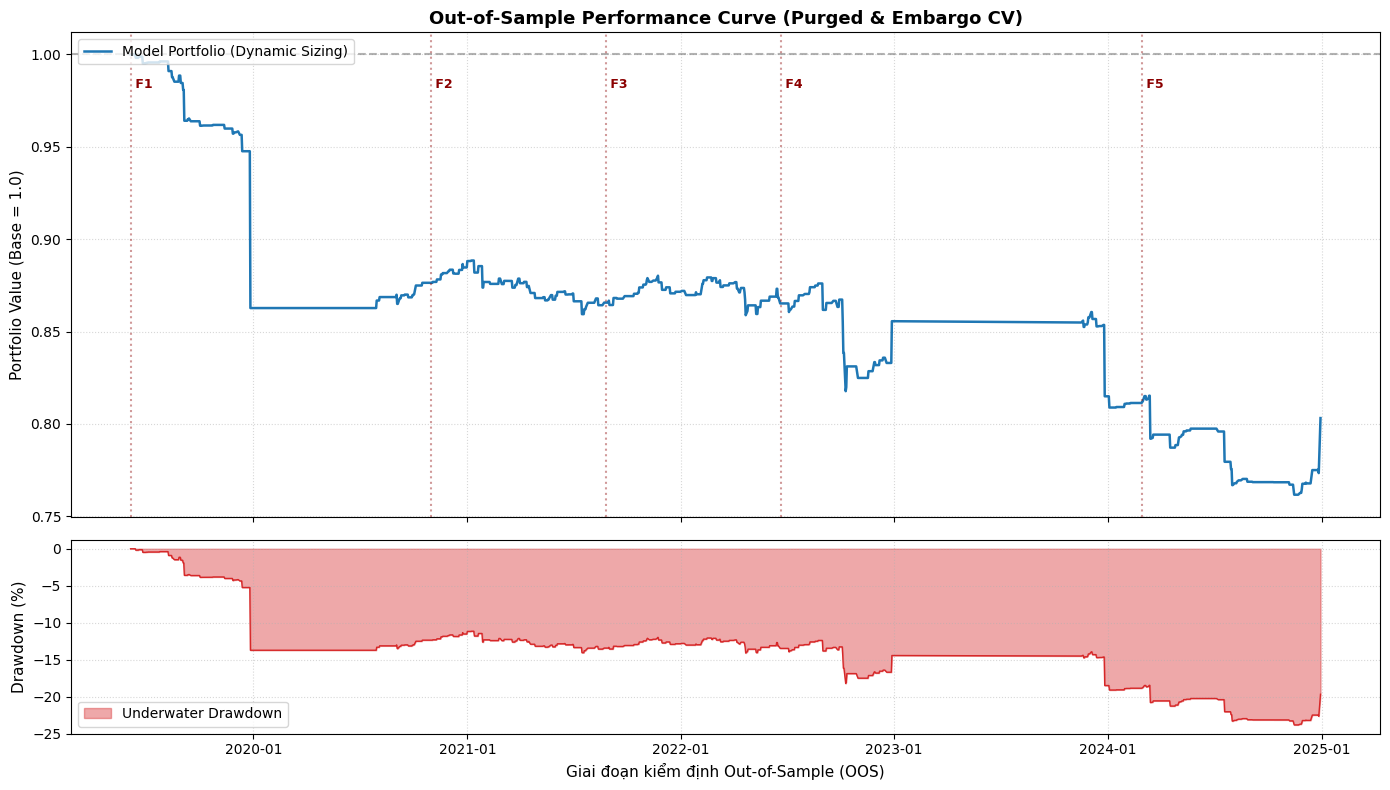


[✓] Đã xuất đồ thị hiệu năng ra file: 'portfolio_performance.png'


In [30]:
# =====================================================================
# 1. QUANTITATIVE BACKTESTING & PERFORMANCE ENGINE
# =====================================================================
class PortfolioBacktestEngine:
    """
    Engine Backtesting chuyên dụng cho Triple Barrier Labels:
    - Xử lý xung đột vị thế giữ lệnh chồng chéo (Overlapping Holding Periods).
    - Tích hợp chi phí giao dịch thực tế (Transaction Fees + Slippage).
    - Hạch toán lợi nhuận có định cỡ quy mô vị thế (Dynamic Bet Sizing).
    - Tính toán toàn bộ bộ chỉ số kinh tế lượng: Sharpe, Sortino, Calmar, Drawdown.
    """
    def __init__(
        self,
        fee_rate: float = 0.0015,       # Phí giao dịch + thuế 2 chiều (~0.15%)
        slippage: float = 0.0005,       # Trượt giá ước lượng (~0.05%)
        annual_factor: int = 252,       # Số phiên giao dịch chuẩn một năm
        risk_free_rate: float = 0.045   # Lãi suất phi rủi ro (4.5%/năm)
    ):
        self.fee_rate = fee_rate
        self.slippage = slippage
        self.cost_per_trade = self.fee_rate + self.slippage
        self.annual_factor = annual_factor
        self.risk_free_rate = risk_free_rate

    def resolve_concurrent_trades(self, df_oos: pd.DataFrame) -> pd.DataFrame:
        """
        Khử xung đột vị thế giữ lệnh chồng chéo theo cơ chế Execution Causal:
        Nếu một lệnh Mua được mở tại thời điểm t và kết thúc (chạm rào) tại t_touch,
        các tín hiệu mua mới phát sinh trong khoảng (t, t_touch) sẽ bị bỏ qua
        nhằm mô phỏng chuẩn xác sức chứa danh mục (Single-Asset Allocation).
        """
        df = df_oos.sort_index().copy()
        df['barrier_touch_time'] = pd.to_datetime(df['barrier_touch_time'])

        active_signals = np.zeros(len(df), dtype=int)
        realized_returns = np.zeros(len(df), dtype=float)
        realized_bets = np.zeros(len(df), dtype=float)

        current_unlock_time = pd.Timestamp.min

        timestamps = df.index
        signals = df['pred_signal'].values
        returns = df['barrier_return'].values
        bets = df['bet_size'].values
        touch_times = df['barrier_touch_time'].values

        for i in range(len(df)):
            t_now = timestamps[i]
            # Chỉ cho phép mở lệnh mới khi vị thế trước đó đã tất toán
            if signals[i] == 1 and t_now >= current_unlock_time:
                active_signals[i] = 1
                realized_returns[i] = returns[i]
                realized_bets[i] = bets[i]
                current_unlock_time = pd.Timestamp(touch_times[i])

        df['executed_signal'] = active_signals
        df['executed_return'] = realized_returns
        df['executed_bet'] = realized_bets

        # Net PnL từng lệnh = (Return * Bet Size) - Chi phí 2 chiều
        df['trade_cost'] = np.where(df['executed_signal'] == 1, 2.0 * self.cost_per_trade * df['executed_bet'], 0.0)
        df['net_trade_pnl'] = (df['executed_return'] * df['executed_bet']) - df['trade_cost']

        # Chuỗi Return tích lũy và Equity Curve
        df['equity_curve'] = (1.0 + df['net_trade_pnl']).cumprod()
        df['peak_equity'] = df['equity_curve'].cummax()
        df['drawdown'] = (df['equity_curve'] - df['peak_equity']) / df['peak_equity']

        return df

    def compute_metrics(self, df_executed: pd.DataFrame, label: str = "Portfolio") -> dict:
        """Tính toán các chỉ số kinh tế lượng chuẩn mực."""
        trades = df_executed[df_executed['executed_signal'] == 1]
        n_trades = len(trades)

        if n_trades == 0:
            return {"Label": label, "Total Trades": 0}

        pnl = trades['net_trade_pnl'].values
        wins = pnl[pnl > 0]
        losses = pnl[pnl < 0]

        win_rate = len(wins) / n_trades if n_trades > 0 else 0.0
        profit_factor = np.sum(wins) / np.abs(np.sum(losses)) if len(losses) > 0 and np.abs(np.sum(losses)) > 0 else np.nan
        avg_win = np.mean(wins) if len(wins) > 0 else 0.0
        avg_loss = np.mean(losses) if len(losses) > 0 else 0.0
        win_loss_ratio = avg_win / np.abs(avg_loss) if avg_loss != 0 else np.nan

        # Chuỗi thời gian PnL theo phiên
        daily_pnl = df_executed['net_trade_pnl'].values
        n_days = len(daily_pnl)
        cumulative_return = df_executed['equity_curve'].iloc[-1] - 1.0

        # Annualized Return (CAGR)
        years = n_days / self.annual_factor
        cagr = (1.0 + cumulative_return) ** (1.0 / years) - 1.0 if years > 0 and cumulative_return > -1.0 else np.nan

        # Annualized Volatility
        ann_vol = np.std(daily_pnl, ddof=1) * np.sqrt(self.annual_factor)

        # Sharpe Ratio (Điều chỉnh theo Risk-Free Rate)
        excess_cagr = cagr - self.risk_free_rate if not np.isnan(cagr) else 0.0
        sharpe = (np.mean(daily_pnl) * self.annual_factor - self.risk_free_rate) / ann_vol if ann_vol > 0 else 0.0

        # Sortino Ratio (Downside Volatility)
        downside_returns = daily_pnl[daily_pnl < 0]
        downside_vol = np.std(downside_returns, ddof=1) * np.sqrt(self.annual_factor) if len(downside_returns) > 1 else 1e-8
        sortino = (np.mean(daily_pnl) * self.annual_factor - self.risk_free_rate) / downside_vol if downside_vol > 0 else 0.0

        # Max Drawdown & Calmar
        max_dd = df_executed['drawdown'].min()
        calmar = cagr / np.abs(max_dd) if max_dd < 0 and not np.isnan(cagr) else np.nan

        return {
            "Label": label,
            "Total Trades": int(n_trades),
            "Win Rate (%)": win_rate * 100.0,
            "Profit Factor": profit_factor,
            "Win/Loss Ratio": win_loss_ratio,
            "Cum. Return (%)": cumulative_return * 100.0,
            "CAGR (%)": cagr * 100.0,
            "Ann. Volatility (%)": ann_vol * 100.0,
            "Sharpe Ratio": sharpe,
            "Sortino Ratio": sortino,
            "Max Drawdown (%)": max_dd * 100.0,
            "Calmar Ratio": calmar,
            "Avg Bet Size": trades['executed_bet'].mean()
        }

    def generate_full_report(self, df_oos_path: str = "df_oos_predictions.csv"):
        # 1. Load và xử lý xung đột
        df_oos = pd.read_csv(df_oos_path, index_col='time', parse_dates=True)
        df_backtest = self.resolve_concurrent_trades(df_oos)

        print("\n" + "=" * 80)
        print("          BÁO CÁO KIỂM TOÁN HIỆU NĂNG TỔNG THỂ (PORTFOLIO PnL AUDIT)")
        print("=" * 80)

        # 2. Tổng hợp toàn bộ chuỗi OOS
        overall_metrics = self.compute_metrics(df_backtest, label="Full OOS Portfolio")

        # 3. Tổng hợp chi tiết theo từng Fold
        fold_metrics_list = []
        for f in sorted(df_backtest['fold'].unique()):
            sub_df = df_backtest[df_backtest['fold'] == f].copy()
            # Tính lại drawdown nội bộ fold
            sub_df['equity_curve'] = (1.0 + sub_df['net_trade_pnl']).cumprod()
            sub_df['peak_equity'] = sub_df['equity_curve'].cummax()
            sub_df['drawdown'] = (sub_df['equity_curve'] - sub_df['peak_equity']) / sub_df['peak_equity']
            fold_metrics_list.append(self.compute_metrics(sub_df, label=f"Fold {f}"))

        summary_df = pd.DataFrame(fold_metrics_list + [overall_metrics]).set_index("Label")
        print(summary_df.round(2).to_string())

        # 4. Trực quan hóa Equity Curve & Drawdown
        self._plot_performance(df_backtest)

        return df_backtest, summary_df

    def _plot_performance(self, df: pd.DataFrame):
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True, gridspec_kw={'height_ratios': [2.5, 1]})

        # Subplot 1: Equity Curve
        ax1.plot(df.index, df['equity_curve'], color='#1f77b4', linewidth=1.8, label='Model Portfolio (Dynamic Sizing)')
        ax1.axhline(1.0, color='gray', linestyle='--', alpha=0.6)
        ax1.set_title('Out-of-Sample Performance Curve (Purged & Embargo CV)', fontsize=13, fontweight='bold')
        ax1.set_ylabel('Portfolio Value (Base = 1.0)', fontsize=11)
        ax1.grid(True, linestyle=':', alpha=0.5)
        ax1.legend(loc='upper left')

        # Đánh dấu vùng các Fold
        for f in df['fold'].unique():
            fold_start = df[df['fold'] == f].index[0]
            ax1.axvline(fold_start, color='darkred', linestyle=':', alpha=0.4)
            ax1.text(fold_start, ax1.get_ylim()[1]*0.97, f' F{f}', color='darkred', fontsize=9, fontweight='bold')

        # Subplot 2: Underwater Drawdown Chart
        ax2.fill_between(df.index, df['drawdown'] * 100, 0, color='#d62728', alpha=0.4, label='Underwater Drawdown')
        ax2.plot(df.index, df['drawdown'] * 100, color='#d62728', linewidth=1.0)
        ax2.set_ylabel('Drawdown (%)', fontsize=11)
        ax2.set_xlabel('Giai đoạn kiểm định Out-of-Sample (OOS)', fontsize=11)
        ax2.grid(True, linestyle=':', alpha=0.5)
        ax2.legend(loc='lower left')

        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        plt.tight_layout()
        plt.savefig("portfolio_performance.png", dpi=300)
        plt.show()
        print("\n[✓] Đã xuất đồ thị hiệu năng ra file: 'portfolio_performance.png'")


# =====================================================================
# 2. THỰC THI KIỂM TOÁN VÀ ĐÁNH GIÁ CUỐI CÙNG
# =====================================================================
engine = PortfolioBacktestEngine(
    fee_rate=0.0015,       # 0.15% phí giao dịch
    slippage=0.0005,       # 0.05% trượt giá
    risk_free_rate=0.045   # Lãi suất phi rủi ro 4.5%
)

df_backtest, summary_metrics = engine.generate_full_report("df_oos_predictions.csv")